## DSND - Fashion Recomendation prediction using NLP and pipelines  

Purpose of this note book is to predict whether or not a customer of a fashion store would recomend a product or not based primarliy on their reviews  
NLP is primarily done using the spaCy library with 'en_core_web_md' model.


### Imports

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np

import spacy
nlp = spacy.load('en_core_web_md')

# Special case rules for spaCy

# Adding these specific categories of rules:
# 1. Sizing and Fit Abbreviations
# Reviewers often use shorthand that can be mistaken for other parts of speech or split incorrectly:
# Size Labels: XS, S/M, XL, XXL. Without a rule, S/M might be split into three tokens ("S", "/", "M").
# 2. Compound Garment Terms
# Fashion language is full of hyphenated or slash-separated terms that should remain together:
# Style Descriptors: high-waisted, v-neck, button-down, off-the-shoulder, t-shirt.

from spacy.symbols import ORTH

# define fashion terms
fashion_terms = ["S/M", "L/XL", "XS","XL","XXL", "high-waisted", "v-neck", "off-the-shoulder", "button-down", "t-shirt"]

for term in fashion_terms:
    nlp.tokenizer.add_special_case(term, [{ORTH: term}])

# Now for example, "This high-waisted skirt is a S/M", will have 'high-waisted' and 'S/M' as single tokens

### Problem framing

This task is framed as:

Binary text classification (recommend vs not recommend)

Labels:

1 = recommends
0 = does not recommend

It is not pure sentiment analysis:

A review can be positive but not recommend (“Nice design but size runs too small”)
A review can be negative but still recommend (“Quality is average, still good for the price”)

✅ So we care about intent to recommend, not just polarity

## Data Exploration  
#### {NOTE: ensure this notebook is in the same folder as the 'data' folder that contains the csv data file to read-in}

The data features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

In [2]:
# Load and check the data
data = pd.read_csv('data/reviews.csv')

data.info()
print()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB



,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


In [3]:
data.describe()

,Clothing ID,Age,Positive Feedback Count,Recommended IND
count,18442.000000,18442.000000,18442.000000,18442.000000
mean,954.896757,43.383635,2.697484,0.816235
std,141.571783,12.246264,5.942220,0.387303
min,2.000000,18.000000,0.000000,0.000000
25%,863.000000,34.000000,0.000000,1.000000
50%,952.000000,41.000000,1.000000,1.000000
75%,1078.000000,52.000000,3.000000,1.000000
max,1205.000000,99.000000,122.000000,1.000000


In [4]:
# ensure feature names do not contain leading or trailing spaces, change spaces to underscore
data.columns = data.columns.str.strip().str.replace(' ','_')
display(data.columns)

Index(['Clothing_ID', 'Age', 'Title', 'Review_Text', 'Positive_Feedback_Count',
       'Division_Name', 'Department_Name', 'Class_Name', 'Recommended_IND'],
      dtype='object')

In [5]:
# check for duplicate entries
data[data.duplicated()]

,Clothing_ID,Age,Title,Review_Text,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Recommended_IND


In [6]:
# check for NaN or infinite values
print(data.isna().sum())
print('\n ------------------- \n')
print(data.isin([np.inf, -np.inf]).sum())

Clothing_ID                0
Age                        0
Title                      0
Review_Text                0
Positive_Feedback_Count    0
Division_Name              0
Department_Name            0
Class_Name                 0
Recommended_IND            0
dtype: int64

 ------------------- 

Clothing_ID                0
Age                        0
Title                      0
Review_Text                0
Positive_Feedback_Count    0
Division_Name              0
Department_Name            0
Class_Name                 0
Recommended_IND            0
dtype: int64


In [7]:
# Separate features from Label/Target
df = data.copy()

X = df.drop('Recommended_IND', axis = 1)
y = df['Recommended_IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing_ID,Age,Title,Review_Text,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


Recommended_IND
1    81.623468
0    18.376532
Name: proportion, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

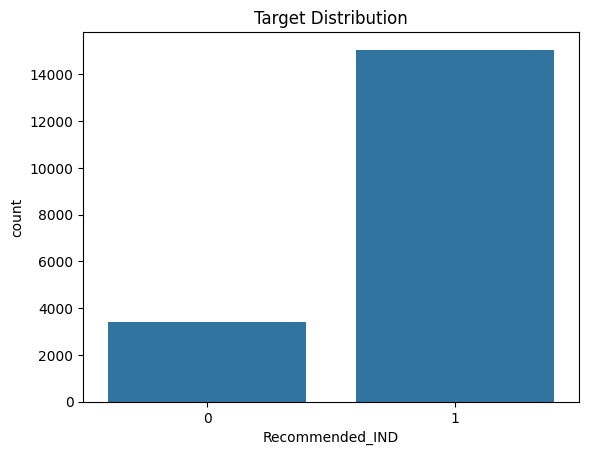

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# check Target imbalance:

print(df['Recommended_IND'].value_counts(normalize=True) * 100)

sns.countplot(x='Recommended_IND', data=df)
plt.title('Target Distribution')
plt.show

#### NOTE: ~80/20 split therefore data set is imbalanced. We will look at ML models that can handle imbalanced binary classification task, eg: RandomForrest. Also look to use a train_test_slit methodology that can account for imbalance maintaining the same class proportions as original data eg: StratifiedShuffleSplit, or Train_Test_Split with 'stratify'

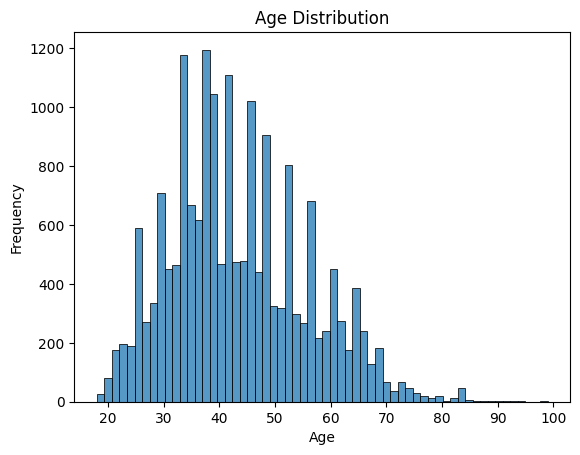

In [9]:
# plot distributions of categorical features and age feature

# Age
sns.histplot(data=df, x='Age', element='bars', fill=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


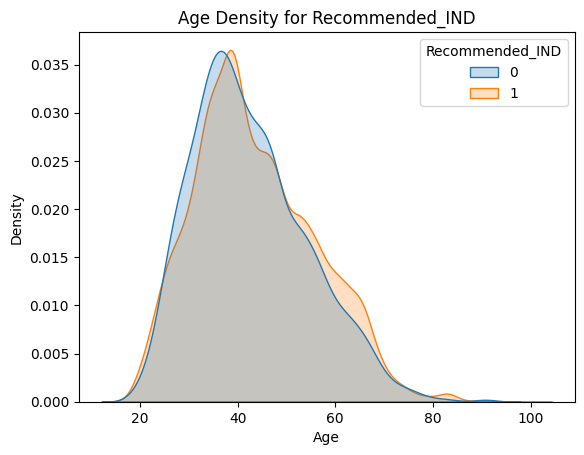

In [10]:
# Density of Age with regards the target label
sns.kdeplot(data=df, x='Age', hue='Recommended_IND', fill=True, common_norm=False)
plt.title('Age Density for Recommended_IND')
plt.show()

#### Age density is near equivalent with respect the imbalanced target, suggesting at this point that Age in itself may not have much influence on the target. Therefore I will keep it as is and not bin it. Perhaps it can be combined with another feature to be more meaningfull. Double cehck for overfitting and Age feature importance when modelling.

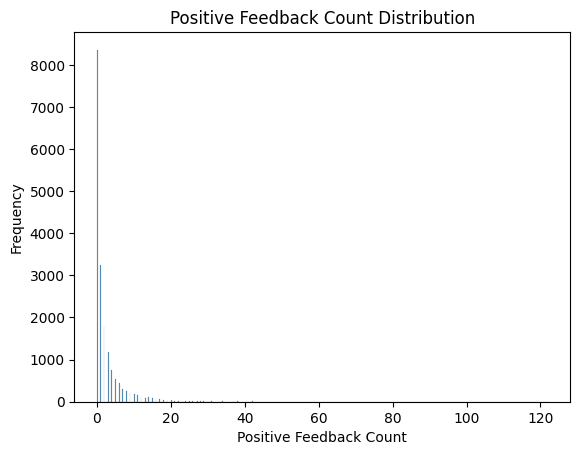

In [11]:
# check distribution of 'Positive_Feedback_Count'

# Positive_Feedback_Count
sns.histplot(data=df, x='Positive_Feedback_Count', element='bars', fill=True)

plt.title('Positive Feedback Count Distribution')
plt.xlabel('Positive Feedback Count')
plt.ylabel('Frequency')
plt.show()

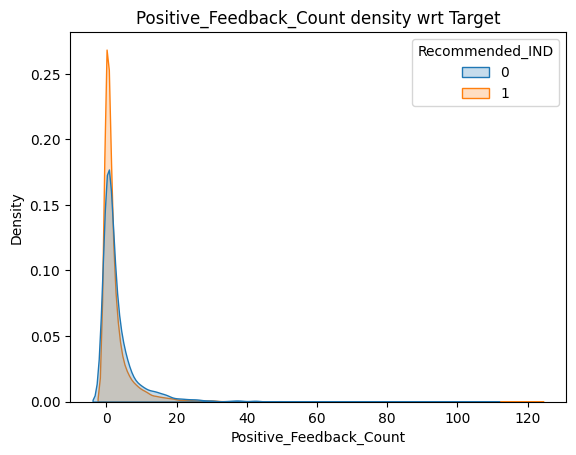

In [12]:
sns.kdeplot(data = df, x='Positive_Feedback_Count', hue='Recommended_IND', fill=True, common_norm=False )
plt.title('Positive_Feedback_Count density wrt Target')
plt.show()

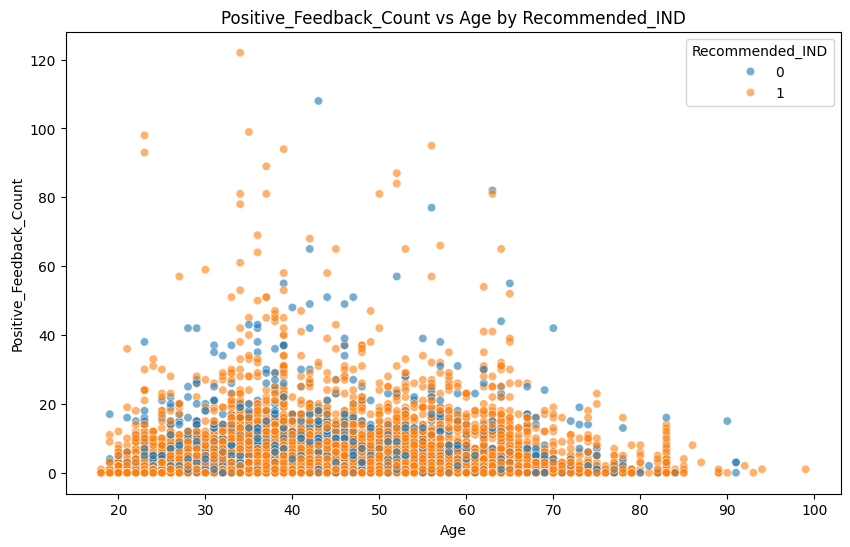

In [13]:
# Positive Feedback Count vs Age
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Positive_Feedback_Count', hue='Recommended_IND', alpha=0.6)

plt.title('Positive_Feedback_Count vs Age by Recommended_IND')
plt.show()

#### Appears that age and other people finding feedback helpfull do not have much of an influence whether or not a an item is recommended or not

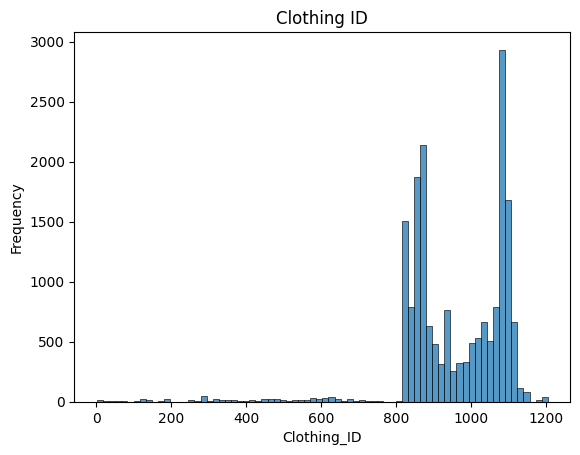

In [14]:
# Distribution of Clothing ID

sns.histplot(data = df, x = 'Clothing_ID', element='bars', fill=True)

plt.title('Clothing ID')
plt.xlabel('Clothing_ID')
plt.ylabel('Frequency')
plt.show()

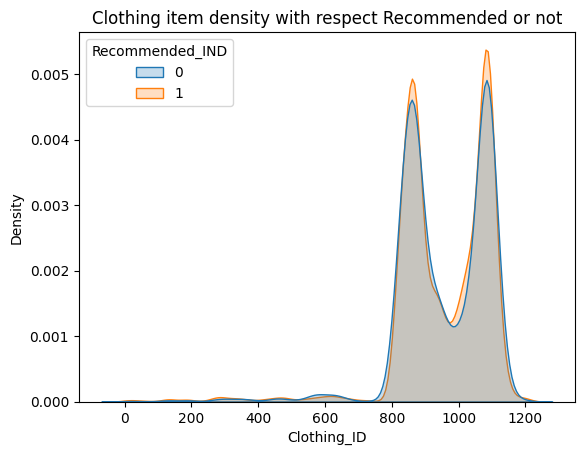

In [15]:
# density of Clothing_ID to target - are there specific items that are more recommended or not recommended??

sns.kdeplot(data = df, x='Clothing_ID', hue='Recommended_IND', common_norm=False, fill=True)
plt.title('Clothing item density with respect Recommended or not')
plt.show()

#### Appears certain items of clothing may sell allot more than others, but the clothing items don't appear to have much bearing on if it is recommended or not.

In [16]:
df['Clothing_ID'].value_counts()

Clothing_ID
1078    871
862     658
1094    651
1081    487
829     452
       ... 
596       1
2         1
587       1
962       1
957       1
Name: count, Length: 531, dtype: int64

Clothing_ID has 531 unique values, high-cardinality, in essetnially a categorical feature. Apply Target Encoder.
 
NOTE all categorical columns do not show any kind of ordinality, therefore transformation should avoid creating ordinality. We look to use Target Encoder (on Clothing_ID) and OneHotEncoder on other categorical features

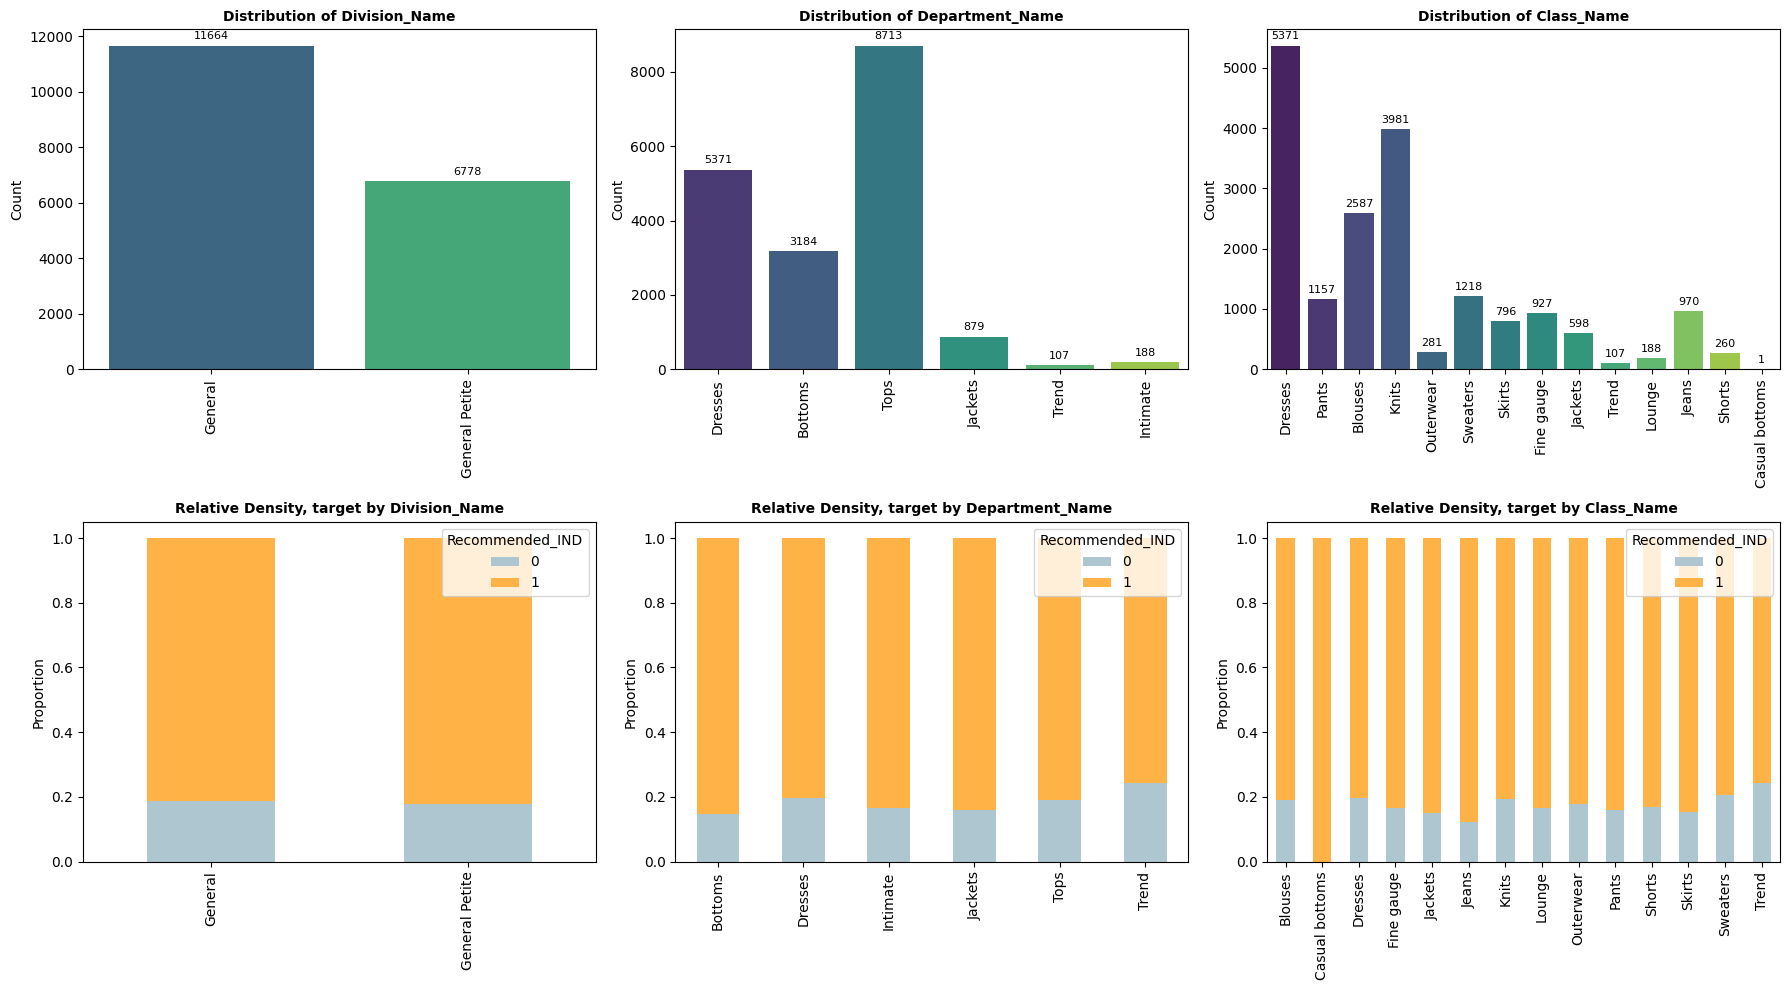

In [17]:
# Histograms and density plots of other categorical features

cat_features = ['Division_Name', 'Department_Name', 'Class_Name']

# setup 2x3 grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18,10))
axes = axes.flatten() # flatten to easily itterate 0 through 5

for i, col in enumerate(cat_features):

    # 1. Create the bar chart (countplot)
    # Using 'hue' ensures each bar is uniquely coloured and labelled
    ax = sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)
    ax.tick_params(axis='x', rotation=90)

    # 2. Add the counts above each bar
    # ax.containers[0] targets the bars in each subplot
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=8)

    # 3. formatting for readability
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')


for i, col in enumerate(cat_features):

    # create density plot
    ct = pd.crosstab(df[col], df['Recommended_IND'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i+3],color=['#aec6cf', '#ffb347']  )

    axes[i+3].set_title(f'Relative Density, target by {col}', fontsize=10, fontweight='bold')
    axes[i+3].set_xlabel('')
    axes[i+3].set_ylabel('Proportion')
    
# final layout adjustment
plt.tight_layout()
plt.show()

Again some items, item types appear to sell allot more than others but distribution against the target is all fairly equivalent and inline with the target class distribution suggesting no major influence over recommended or not

I would go as far as saying that its only the text features that would be able to help with recommendation inference and that we could possibly combine Division_Name/Department_Name/Class_Name/ into 1 feature. I may want to delete the 1 'Casual bottoms' record as that may influence a decision specifically. Then explore the text features further

### Text feature engineering and exploration

The kinds of things I will look at/explore:  
Count of words, count total chars, count of exclamation and question punctuation and parenthesis,   
count of tokens after lemmatisation (or lemmatisation?), POS tagging,  
Incldue special case rules like 't-shirt' to stop it from being split  
HuggingFace sentiment  
TFIDF vectors  

NOTE: don't remove stop words so that you keep bigram (the negative)

In [18]:
# concatenate Title and Review text features
df['Title__Review'] = df['Title'] + '__' + df['Review_Text']

display(df.head())

,Clothing_ID,Age,Title,Review_Text,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Recommended_IND,Title__Review
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0,Some major design flaws__I had such high hopes...
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1,"My favorite buy!__I love, love, love this jump..."
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1,Flattering shirt__This shirt is very flatterin...
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0,Not for the very petite__I love tracy reese dr...
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1,Cagrcoal shimmer fun__I aded this in my basket...


In [19]:
# Get total char count, total word count and count of exclamation, question and parenthesis
df['total_char_count'] = df['Title__Review'].str.len()
df['word_count'] = df['Title__Review'].str.split().fillna('').str.len()
df['count_exclamation'] = df['Title__Review'].str.count('!')
df['count_question'] = df['Title__Review'].str.count(r'\?') # ? is a regex character so needs to be escaped
df['count_parenthesis'] = df['Title__Review'].str.count(r'[\(\)]') # () are regex characters so need to be escaped

display(df.head())

,Clothing_ID,Age,Title,Review_Text,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Recommended_IND,Title__Review,total_char_count,word_count,count_exclamation,count_question,count_parenthesis
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0,Some major design flaws__I had such high hopes...,525,101,1,0,4
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1,"My favorite buy!__I love, love, love this jump...",142,24,3,0,0
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1,Flattering shirt__This shirt is very flatterin...,210,37,3,0,0
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0,Not for the very petite__I love tracy reese dr...,513,102,0,0,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1,Cagrcoal shimmer fun__I aded this in my basket...,518,103,0,0,7


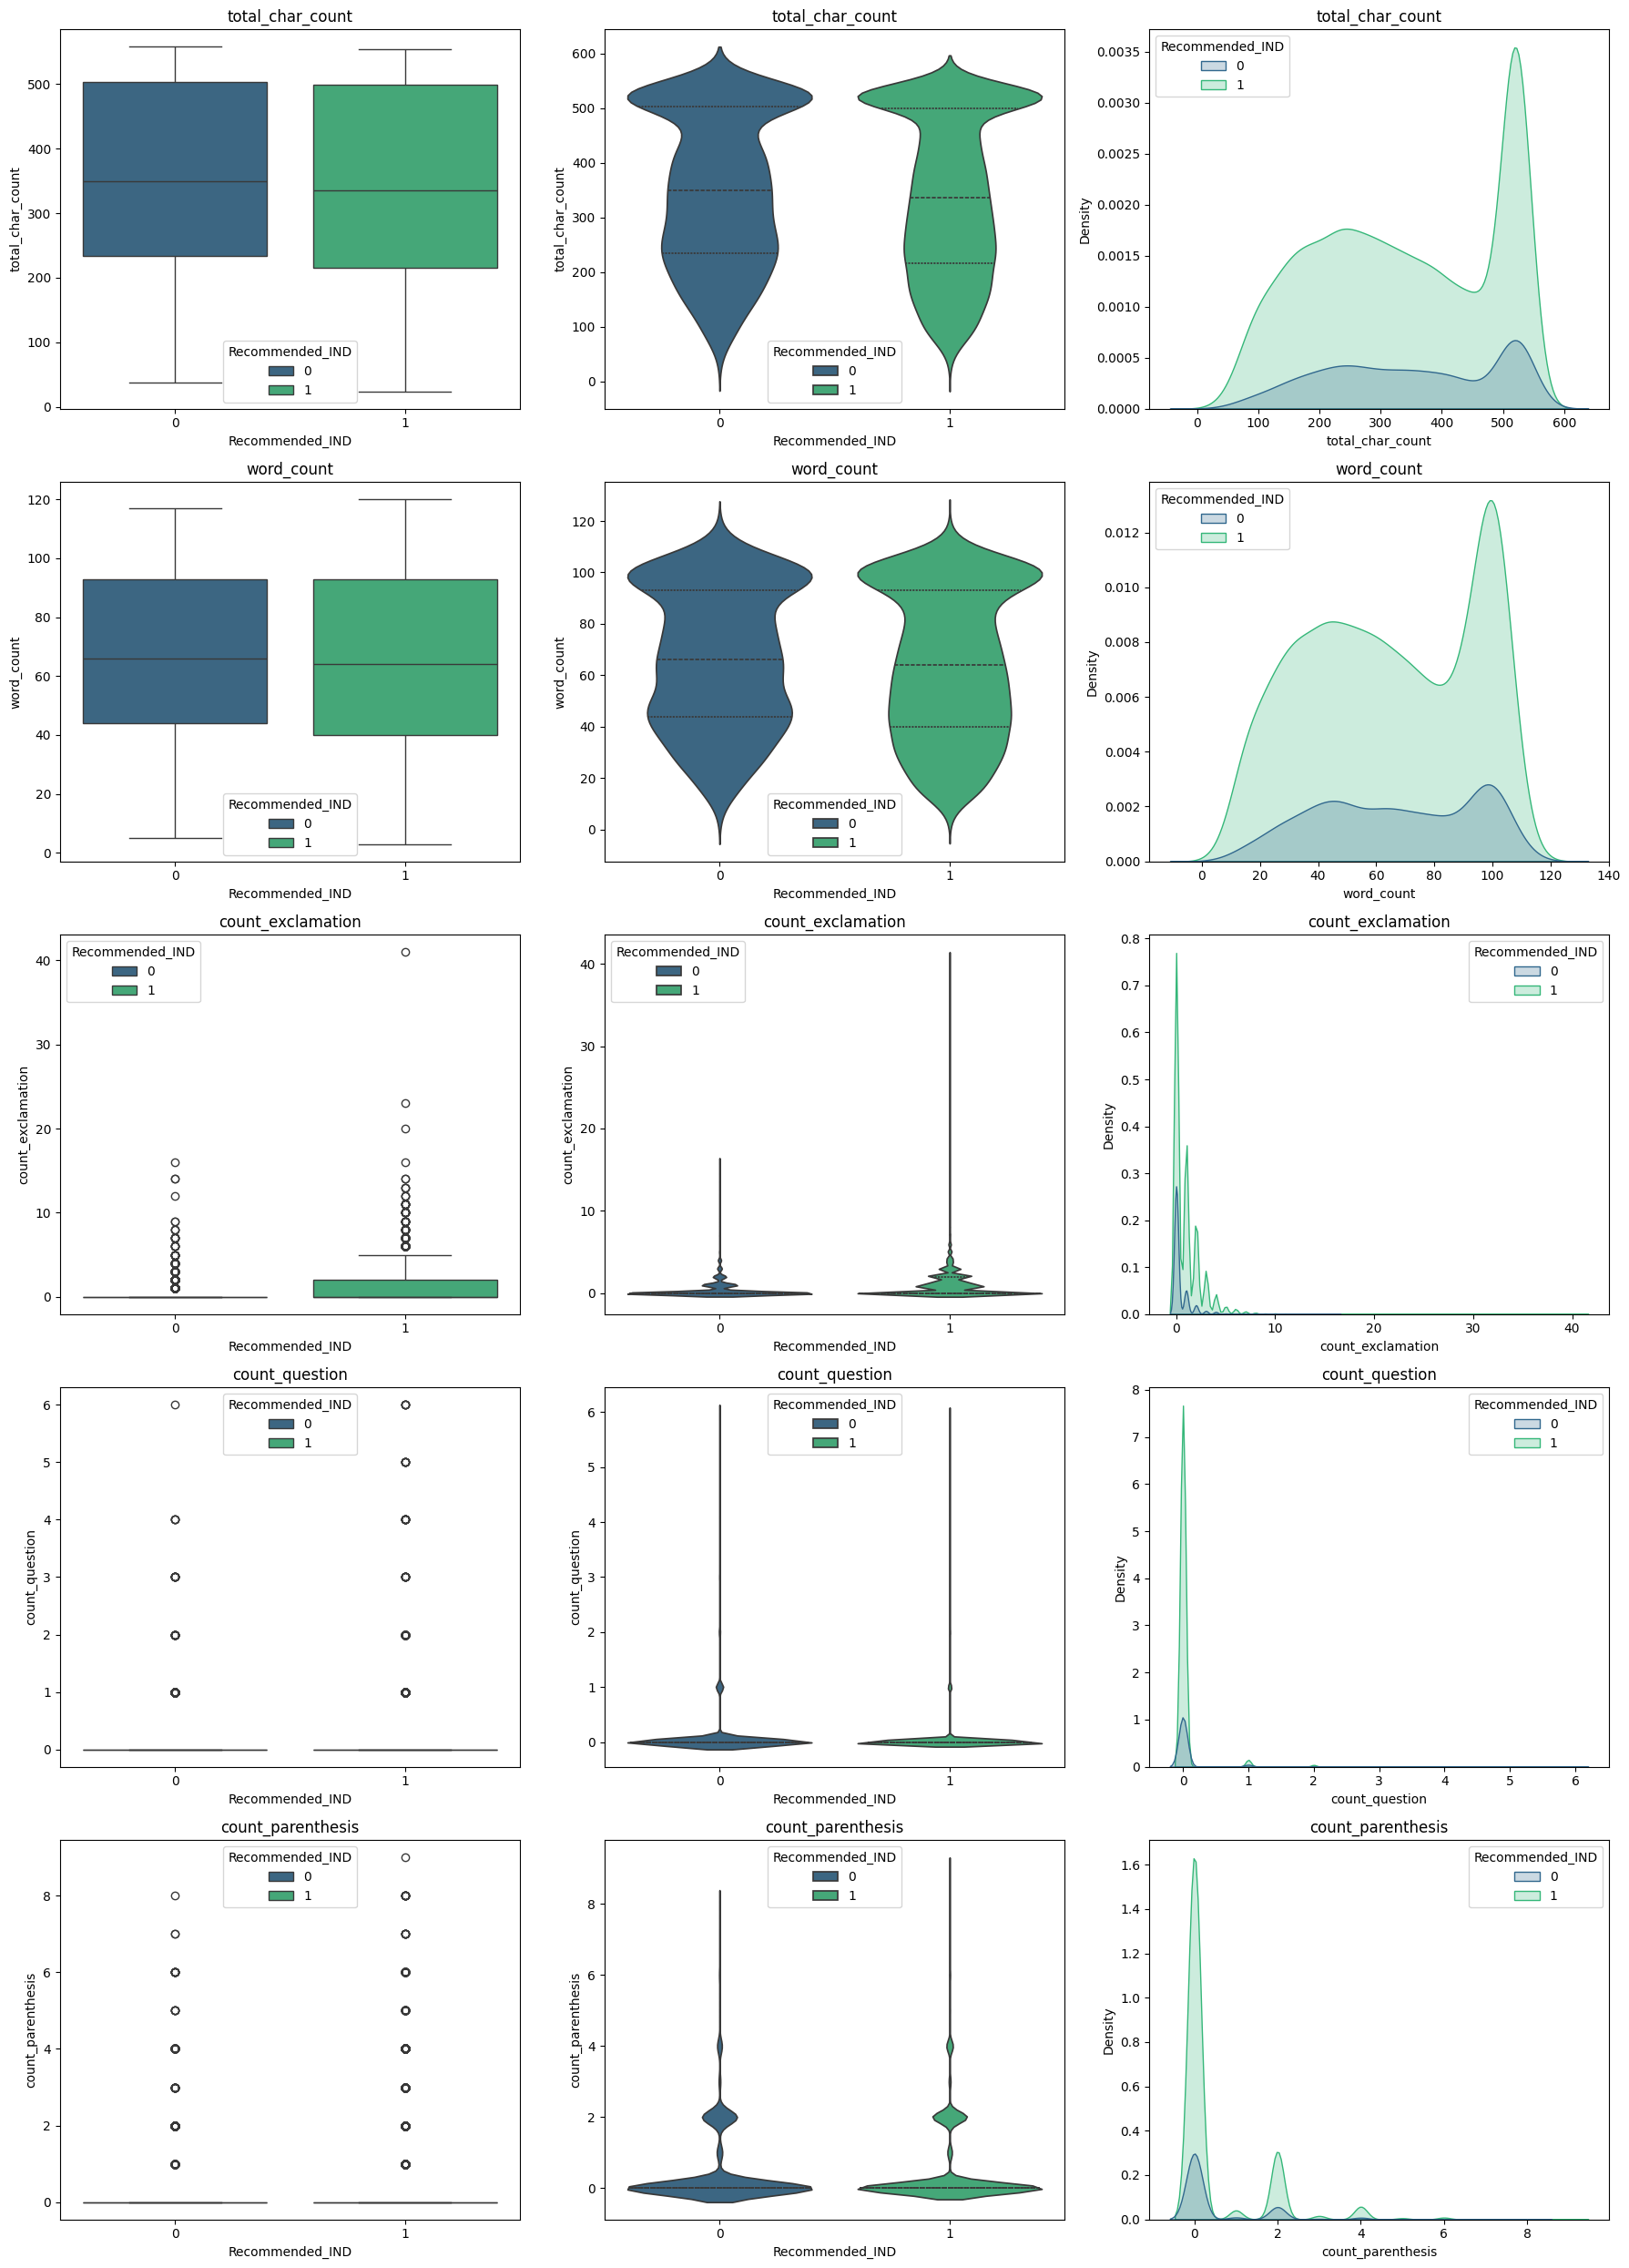

In [20]:
# check distribtuion/correlation of new count features against the target
count_features = ['total_char_count', 'word_count', 'count_exclamation', 'count_question', 'count_parenthesis']

# create a grid 5 rows and 3 columns
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18,25))
target = 'Recommended_IND'

for i, col in enumerate(count_features):

    # row i, col 0: Box plot
    sns.boxplot(ax = axes[i,0], data=df, x=target, y=col, hue=target, palette='viridis')
    axes[i,0].set_title(f'{col}')

    # row i, col 1: Voilin plot
    sns.violinplot(ax=axes[i,1], data=df, x=target, y=col, hue=target, palette='viridis', inner='quart')
    axes[i,1].set_title(f'{col}')

    # ro i, col 2: kde plot
    sns.kdeplot(ax=axes[i, 2], data=df, x=col, hue=target, fill=True, palette='viridis')
    axes[i,2].set_title(f'{col}')

plt.tight_layout()
plt.show()

from the above it appears that only exclamation count might have some influence on target decision, and perhaps word_count some small influence on 'not recomended' as the shape of the owrd_count violin tends to bloat around word count 40, however the density plot say this would be very minimal.   


Now lets try creating features with spaCy   

What does spaCy do:  
Tokenization: This is always the first step. spaCy segments the text into individual units (tokens) like words, punctuation, and whitespace. 
Part-of-Speech (POS) Tagging: Assigns grammatical categories like NOUN, VERB, or ADJ to each token.  
Dependency Parsing: Analyses the sentence structure to find relationships between words (e.g., which noun is the subject of which verb). 
Lemmatization: Reduces words to their base or dictionary form (e.g., "running" becomes "run").  
Named Entity Recognition (NER): Identifies "real-world" objects like names of people, companies, or locations.  
Attribute Assignment: Sets flags on tokens such as .is_stop (is it a stop word?), .is_punct, or .like_num

Let us create the following: Adjective Count, Verb Count, Entity Count, Noun Chunk Count, Avg Chunk Length, Avg Sentence Length, Stop Word Ratio. 

In [21]:
# function to extract spacy features 
def extract_spacy_features(text_series, batch_size=50):

    results = []

 # nlp.pipe yields one 'doc' at a time from the 'texts' list so you have to itterate through it
 # 'texts' is a Pandas Series 
    for doc in nlp.pipe(text_series.astype(str), batch_size=batch_size):

        # extract noun chunks
        chunks = list(doc.noun_chunks)
        chunk_count = len(chunks)

        # average chunk length in tokens
        avg_chunk_length = sum(len(chunk) for chunk in chunks) / max(1, chunk_count)

        # extract sentence stats
        sentences = list(doc.sents)
        sentence_count = len(sentences)
        avg_sent_len = sum(len(s) for s in sentences) / max(1, sentence_count)

        # token level stats
        adjectives = [t for t in doc if t.pos_ == 'ADJ']
        verbs = [t for t in doc if t.pos_ == 'VERB']
        stop_words = [t for t in doc if t.is_stop]

        # named entities
        entities = list(doc.ents)

        # apend the above as a dictionary for easy dataframe conversion
        results.append({
            'adj_count': len(adjectives),
            'verb_count': len(verbs),
            'entity_count': len(entities),
            'avg_sentence_len': avg_sent_len,
            'noun_chunk_count': chunk_count,
            'avg_chunk_len': avg_chunk_length,
            'stop_word_ratio': len(stop_words) / max(1, len(doc))
        })

    return pd.DataFrame(results)

In [22]:
# add spacy features to the dataframe
spacy_features_df = extract_spacy_features(df['Title__Review'])
df = pd.concat([df, spacy_features_df], axis=1)

display(df.head())

,Clothing_ID,Age,Title,Review_Text,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Recommended_IND,Title__Review,...,count_exclamation,count_question,count_parenthesis,adj_count,verb_count,entity_count,avg_sentence_len,noun_chunk_count,avg_chunk_len,stop_word_ratio
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0,Some major design flaws__I had such high hopes...,...,1,0,4,18,9,1,22.800000,27,1.962963,0.473684
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1,"My favorite buy!__I love, love, love this jump...",...,3,0,0,2,3,0,11.000000,12,1.250000,0.363636
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1,Flattering shirt__This shirt is very flatterin...,...,3,0,0,7,3,0,14.000000,10,1.900000,0.523810
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0,Not for the very petite__I love tracy reese dr...,...,0,0,0,5,7,2,15.857143,25,1.840000,0.576577
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1,Cagrcoal shimmer fun__I aded this in my basket...,...,0,0,7,6,17,2,17.285714,32,1.375000,0.454545


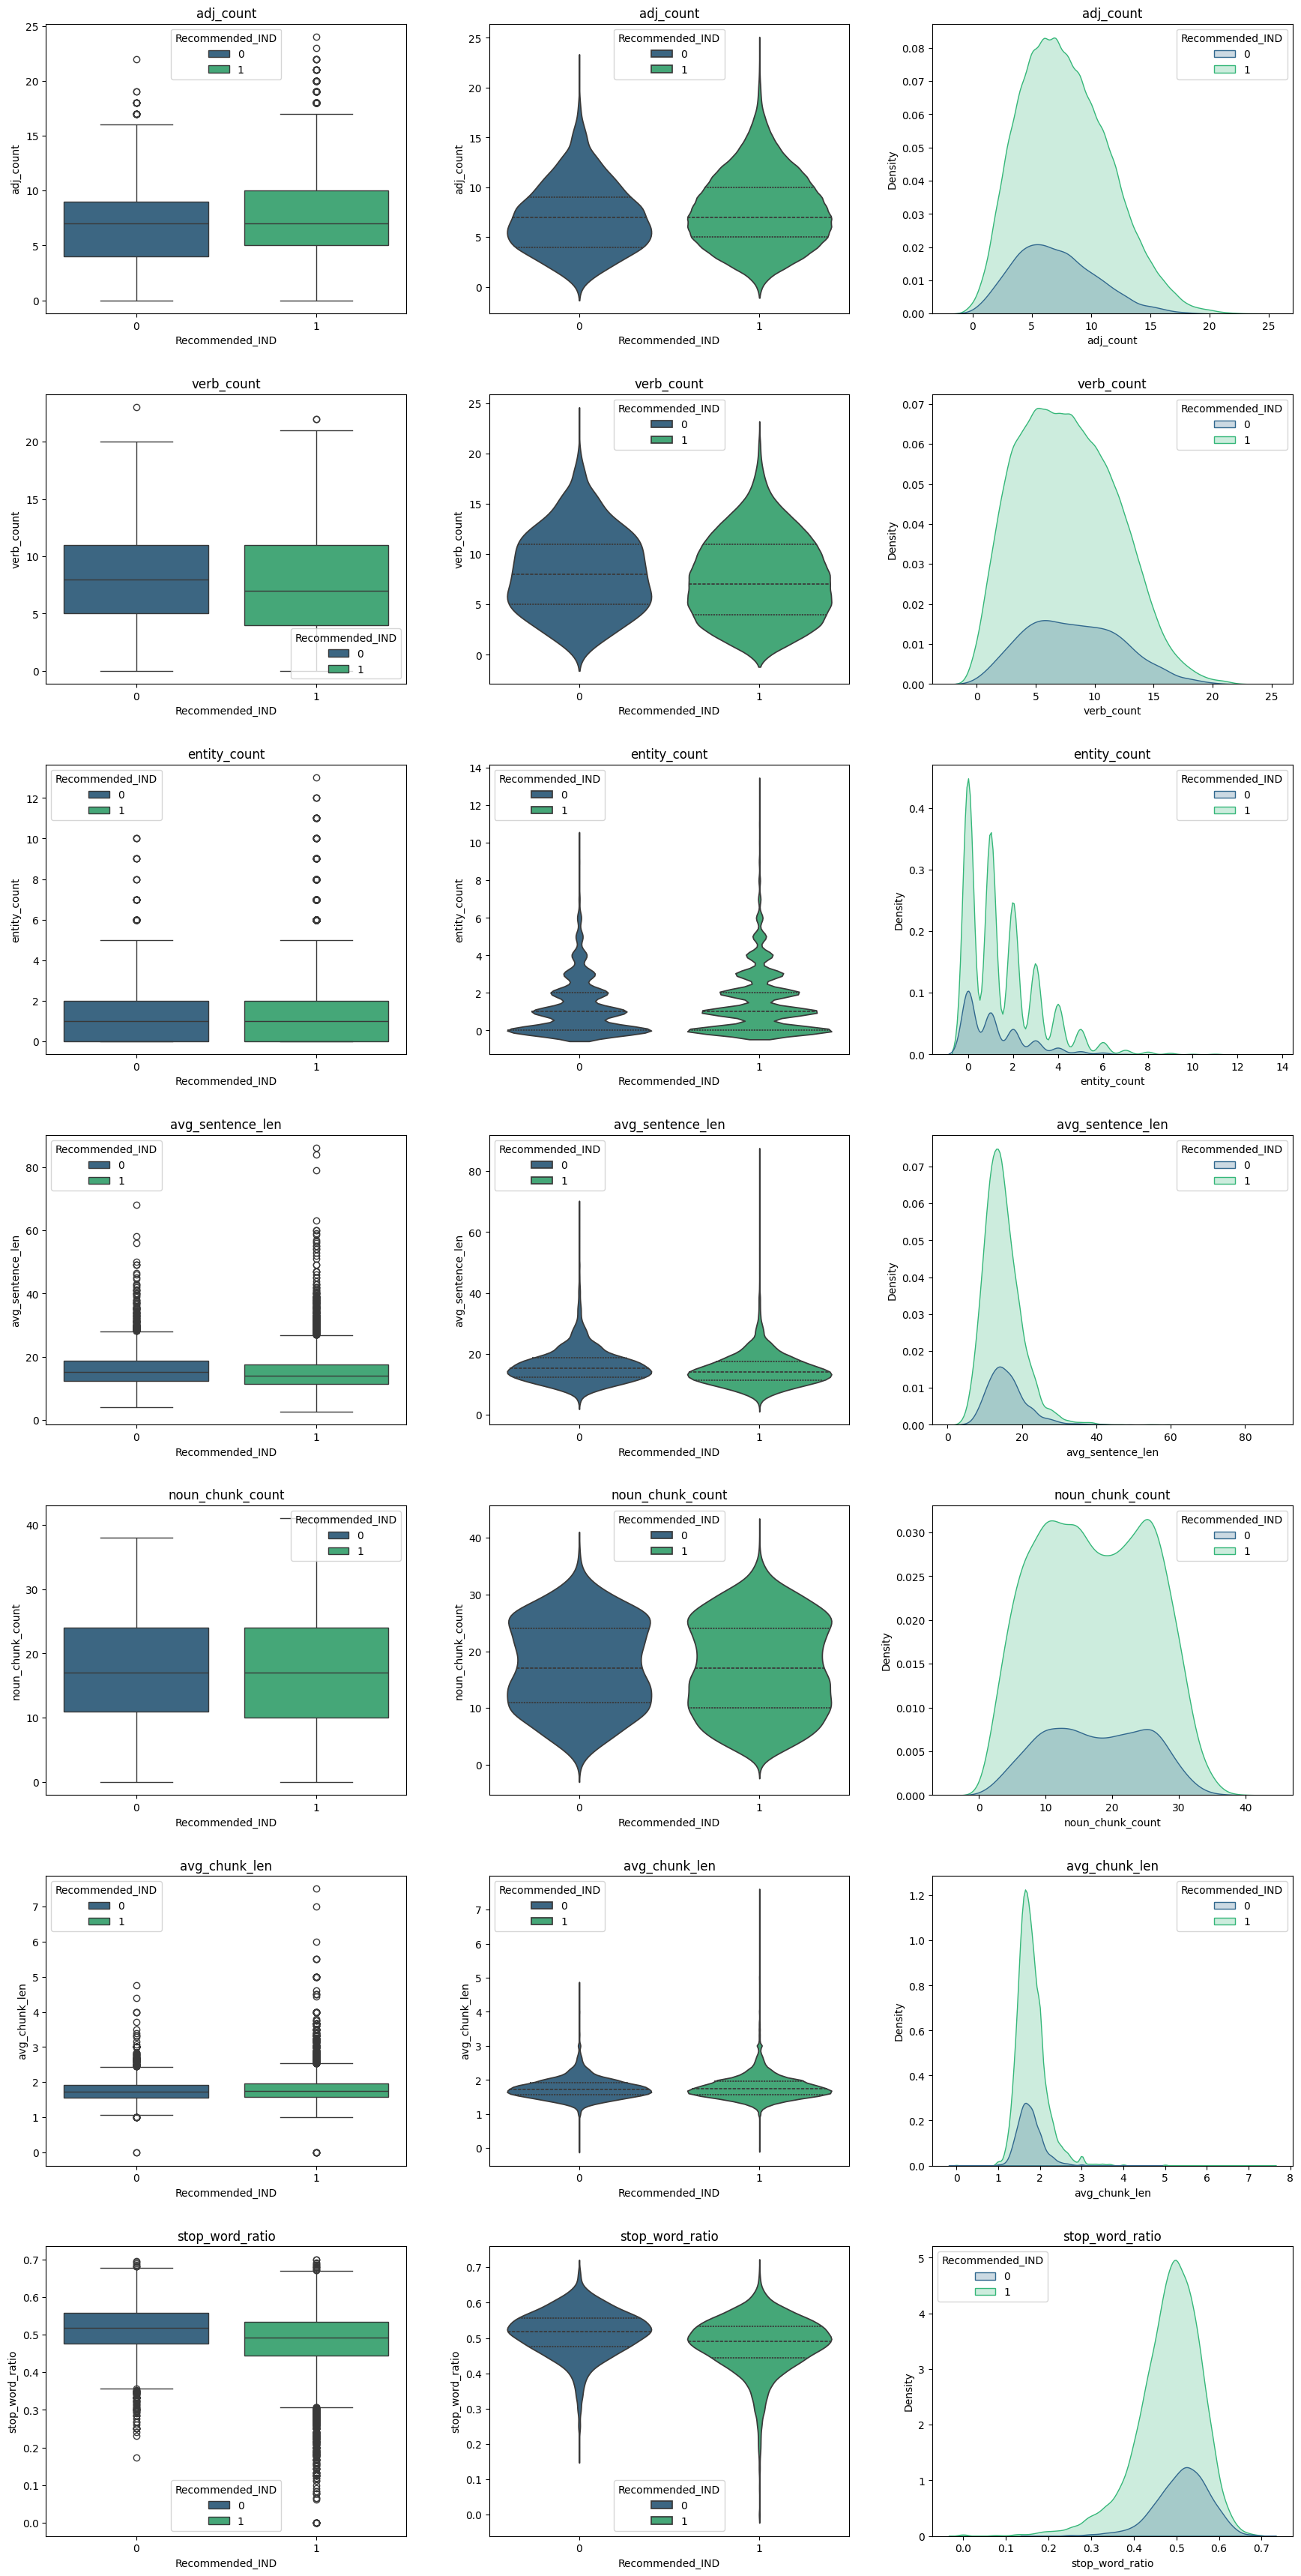

In [23]:
# check distribtuion/correlation of new 'spacy' features against the target
spacy_features = ['adj_count', 'verb_count','entity_count', 'avg_sentence_len', 'noun_chunk_count', 'avg_chunk_len', 'stop_word_ratio']

# create a grid 7 rows and 3 columns
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(18,35))
target = 'Recommended_IND'

for i, col in enumerate(spacy_features):

    # row i, col 0: Box plot
    sns.boxplot(ax = axes[i,0], data=df, x=target, y=col, hue=target, palette='viridis')
    axes[i,0].set_title(f'{col}')

    # row i, col 1: Voilin plot
    sns.violinplot(ax=axes[i,1], data=df, x=target, y=col, hue=target, palette='viridis', inner='quart')
    axes[i,1].set_title(f'{col}')

    # ro i, col 2: kde plot
    sns.kdeplot(ax=axes[i, 2], data=df, x=col, hue=target, fill=True, palette='viridis')
    axes[i,2].set_title(f'{col}')

plt.tight_layout(pad=3.0)
plt.show()

Notes: spaCy generated features:  
from the above it appears the spaCy generated features would do a slightly better job of helping to diferentiate between target values than the more basic features created prior, more particularly adjective and verb count, possibly also stop_word_ratio

Now lets create a sentiment feature for the reviews  
We'll use DistilBERT SST-2 pretrained model that is fine tuned for sentiment and use its sentiment score - converting a 'Negative' label to a negative sentiment score  
Then we'll check this sentiment score against the target 


In [24]:
# Function to run and add HF Sentiment analysis feature

# DistilBERT SST-2 pretrained model that is fine tuned for sentiment and use its sentiment score - converting a 'Negative' label to a negative sentiment score
# the function also checks for a cache of the sentiment analysis that may have been previously run and saved to disk to help save time

import os
from transformers import pipeline
from tqdm.auto import tqdm # a library that allows us to add a visual progress bar for long running operations

def hfSentimentAnalysis(input_text, cache_file = 'sentiment_score.csv', model_name='distilbert-base-uncased-finetuned-sst-2-english', batch_size=8, classifier=None):
        
    # handle input ensuring we get a string only text series
    if isinstance(input_text, pd.DataFrame):
        text_series = input_text.iloc[:,0].astype(str)
    else:
        text_series = pd.Series(np.array(input_text).ravel()).astype(str)

    # 1. check if saved/cached scores exists in file name given
    if os.path.exists(cache_file):
        print(f'Loading existing sentiment analysis from {cache_file}')
        scores = pd.read_csv(cache_file).iloc[:,0].tolist()

        # do basic validation of the input/cached sentiment analysis - ensure loaded data matches the input text_series length
        
        if len(scores) != len(text_series):
            
            print(f'Cached sentiment length mis-match! Cache len {len(scores)}, Text_Series len {len(text_series)}. Re-running sentiment analysis classifier...')

        else: # return the sentiment analysis feature as a Series
            return pd.Series(scores, index=text_series.index, name='sentiment_score')
            
    # 2. Run classifier if no cache or mismatch
    print(f'Running sentiment classifier...')

    # instantiate the classifier
    if classifier is None:
        classifier = pipeline('sentiment-analysis', model= model_name)

    # convert to a list for the piepline
    texts = text_series.to_list()

    # use tqdm to show progress of analysis accross batches
    sentiment_results = []

    for i in tqdm(range(0, len(texts), batch_size), desc='Processing Sentiment Analysis...'):

        batch = texts[i : i + batch_size]

        results = classifier(
            batch, 
            truncation=True,    # prevents crashes on long reviews
            padding=True        # makes all reviews the same length for faster processing
        )
        sentiment_results.extend(results)

    
    # 3. calculate final sentiment scores, ensureing a range from -1 to +1
    scores = [
        res['score'] * (-1 if res['label'] == 'NEGATIVE' else 1) for res in sentiment_results
    ]
        
    # 4. save to disk for a next use to avoid re-running the classifier every time
    pd.Series(scores).to_csv(cache_file, index=False)
    print(f'Saved sentiment scores to {cache_file}')

    return pd.Series(scores, index=text_series.index, name='sentiment_score')

In [25]:
# Add Sentiment Score feature using HuggingFace DistilBERT SST-2 pretrained model
df['sentiment_score'] = hfSentimentAnalysis(df['Title__Review'])

display(df.head())

Loading existing sentiment analysis from sentiment_score.csv


,Clothing_ID,Age,Title,Review_Text,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Recommended_IND,Title__Review,...,count_question,count_parenthesis,adj_count,verb_count,entity_count,avg_sentence_len,noun_chunk_count,avg_chunk_len,stop_word_ratio,sentiment_score
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0,Some major design flaws__I had such high hopes...,...,0,4,18,9,1,22.800000,27,1.962963,0.473684,0.983360
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1,"My favorite buy!__I love, love, love this jump...",...,0,0,2,3,0,11.000000,12,1.250000,0.363636,0.999879
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1,Flattering shirt__This shirt is very flatterin...,...,0,0,7,3,0,14.000000,10,1.900000,0.523810,0.999553
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0,Not for the very petite__I love tracy reese dr...,...,0,0,5,7,2,15.857143,25,1.840000,0.576577,-0.869889
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1,Cagrcoal shimmer fun__I aded this in my basket...,...,0,7,6,17,2,17.285714,32,1.375000,0.454545,0.742803


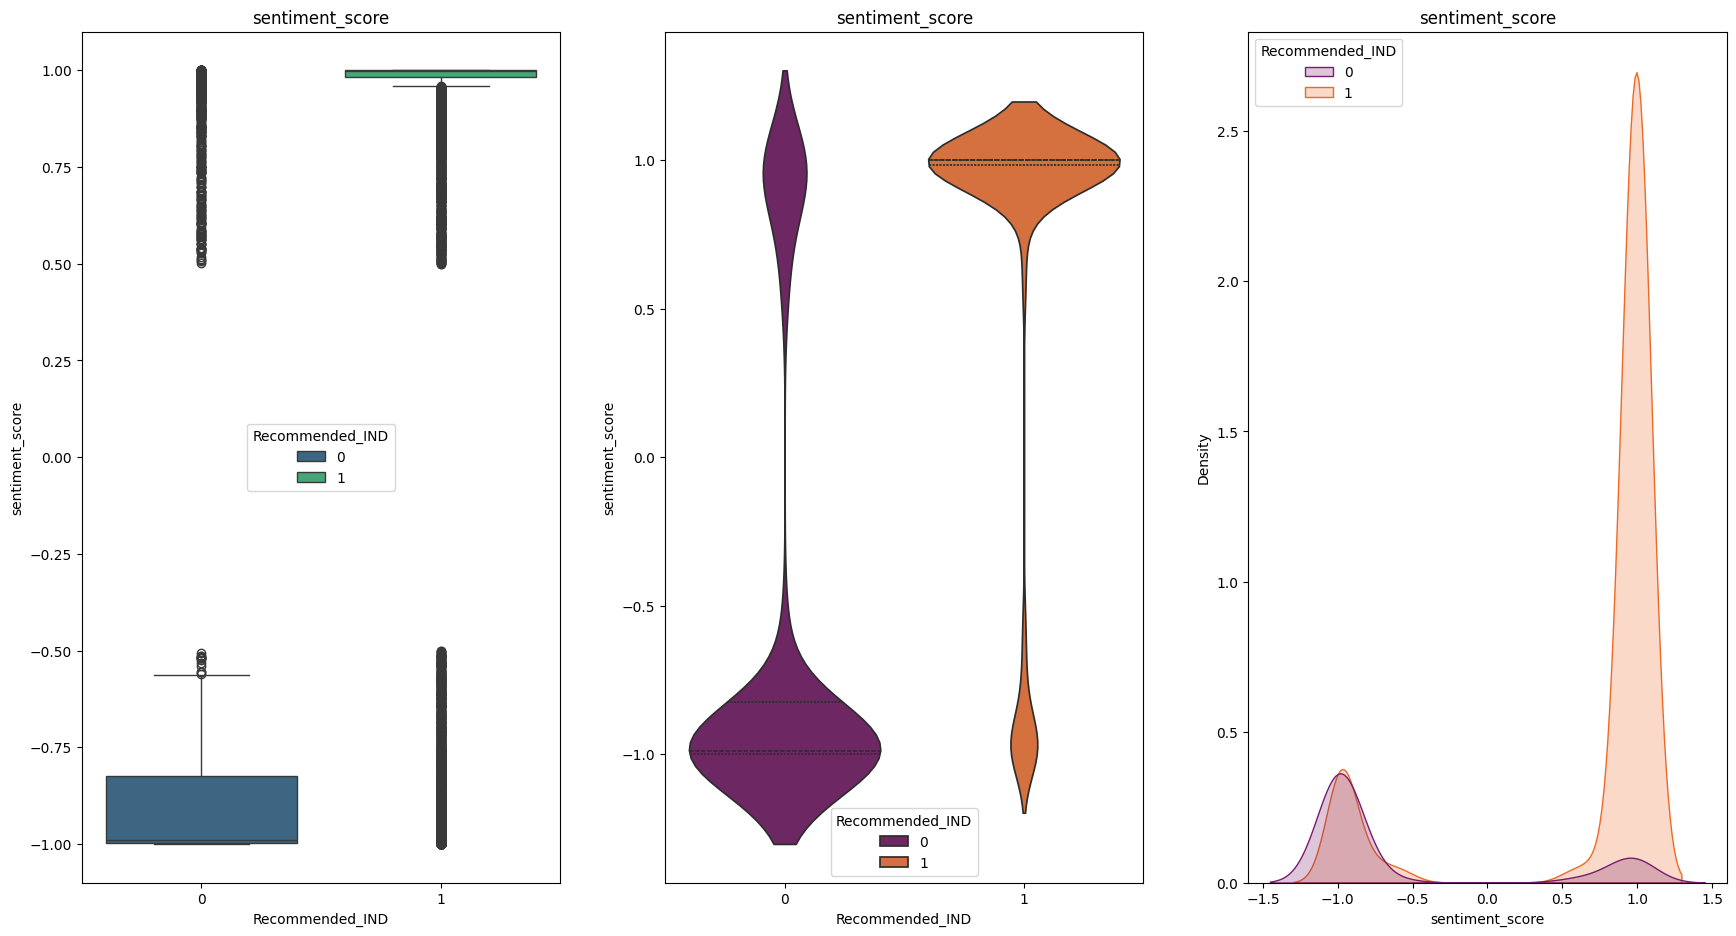

In [26]:
# check distribtuion/correlation of new 'sentiment_score' feature against the target
features = ['sentiment_score']

# create a grid 7 rows and 3 columns
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,10))
target = 'Recommended_IND'

for i, col in enumerate(features):

    # row i, col 0: Box plot
    sns.boxplot(ax = axes[0], data=df, x=target, y=col, hue=target, palette='viridis')
    axes[0].set_title(f'{col}')

    # row i, col 1: Voilin plot
    sns.violinplot(ax=axes[1], data=df, x=target, y=col, hue=target, palette='inferno', inner='quart')
    axes[1].set_title(f'{col}')

    # ro i, col 2: kde plot
    sns.kdeplot(ax=axes[2], data=df, x=col, hue=target, fill=True, palette='inferno')
    axes[2].set_title(f'{col}')

plt.tight_layout(pad=3.0)
plt.show()

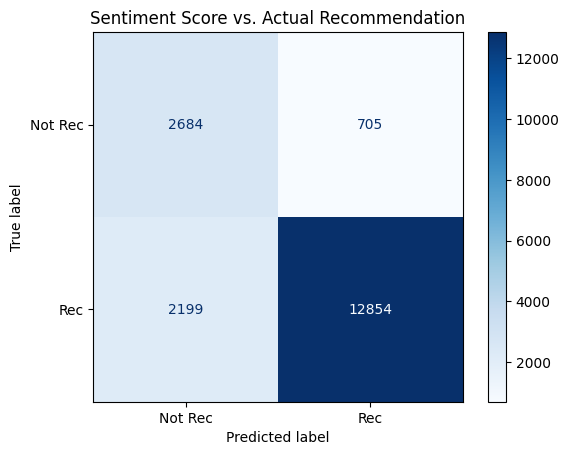

In [27]:
# Confusion Matrix view of the HuggingFace sentiment score against target 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df['sentiment_binary'] = np.where(df['sentiment_score'] > 0, 1, 0)

# 1. Compute the matrix
# Rows = Actual (Recommended_IND), Columns = Predicted (sentiment_binary)
cm = confusion_matrix(df['Recommended_IND'], df['sentiment_binary'])

# 2. Plot the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Rec', 'Rec'])
disp.plot(cmap='Blues')
plt.title("Sentiment Score vs. Actual Recommendation")
plt.show()

Note - while the HuggingFace sentiment analysis takes ~20 mins to run on my PC (that does not have a GPU!) its clear that it may have fair influence on the target, although a concern being 'False Negatives' - but hopefully one would see less of that in classification which will use the continuous 'sentiment_sore' values as apposed to the binary conversion for the confusion matrix. So I'll likely include it as a feature.  

Then I will also create TF-IDF vectors for use in classification


####                                                ----------------- End of EDA Section ----------------

## Data Preparation

In [28]:
# split the data set and create 'train/test' sets

df = data.copy()

# ensure feature names do not contain leading or trailing spaces, change spaces to underscore
df.columns = df.columns.str.strip().str.replace(' ','_')
display(df.columns)

df = df.reset_index(drop=True)

Index(['Clothing_ID', 'Age', 'Title', 'Review_Text', 'Positive_Feedback_Count',
       'Division_Name', 'Department_Name', 'Class_Name', 'Recommended_IND'],
      dtype='object')

#### NOTE: As I have found out the hard way, 🤦‍♂️, the HF sentiment analysis feature creation and Lemmatisation is computationally expensive, especially when trying to tune hyperparameters as it gets run for every cross validation fold. Given that in my context here, these are essentialy static preprocessing steps that then get used as features, I will run them once for the entire data set outside of the overall pipeline to avoid the unnecessary repeated computations

#### However, further down in the notebook, where I have created my transformer classes, I have also created a custom Sentiment Analysis and Spacy Lemmatiser transformers to show that such step could be included in a pipeline

In [29]:
# function to run Spacy Lemmatisation to add into the dataframe as a feature for TFIDF vectorisation in the pipeline

def textLemmatizer(input_text, nlp, batch_size=256):
       
    # handle input and ensure we get a string only series
    if isinstance(input_text, pd.DataFrame):
        text_series = input_text.iloc[:,0].astype(str)
    else:
        text_series = pd.Series(np.array(input_text).ravel()).astype(str)

    lemmatized_texts = []

    # use nlp.pipe which should use optimised batch processing and be faser than nlp(text)
    for doc in tqdm(nlp.pipe(text_series, batch_size=batch_size), total=len(text_series), desc='Lemmatizing...'):

        # join lemmas with a space
        lemmatized_texts.append(' '.join([token.lemma_ for token in doc]))
       
    print(f'CHeck length of: input rows {len(input_text)} and converted text_series: {len(text_series)} and output length: {len(lemmatized_texts)}')

    return pd.Series(lemmatized_texts, index=text_series.index, name='lemmatized_text')


In [30]:
# concatenate Title and Review text features
df['Title__Review'] = df['Title'] + '__' + df['Review_Text']

df.drop(columns=['Title', 'Review_Text'], inplace=True)

display(df.head())

,Clothing_ID,Age,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Recommended_IND,Title__Review
0,1077,60,0,General,Dresses,Dresses,0,Some major design flaws__I had such high hopes...
1,1049,50,0,General Petite,Bottoms,Pants,1,"My favorite buy!__I love, love, love this jump..."
2,847,47,6,General,Tops,Blouses,1,Flattering shirt__This shirt is very flatterin...
3,1080,49,4,General,Dresses,Dresses,0,Not for the very petite__I love tracy reese dr...
4,858,39,1,General Petite,Tops,Knits,1,Cagrcoal shimmer fun__I aded this in my basket...


In [31]:
# add lemmatised column feature - avoiding unnecessary future computations, especially in model hyper parameter tuning
df['lemmatised_text'] = textLemmatizer(df['Title__Review'], nlp=nlp)

display(df.head())

Lemmatizing...:   0%|          | 0/18442 [00:00<?, ?it/s]

CHeck length of: input rows 18442 and converted text_series: 18442 and output length: 18442


,Clothing_ID,Age,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Recommended_IND,Title__Review,lemmatised_text
0,1077,60,0,General,Dresses,Dresses,0,Some major design flaws__I had such high hopes...,some major design flaws__I have such high hope...
1,1049,50,0,General Petite,Bottoms,Pants,1,"My favorite buy!__I love, love, love this jump...","my favorite buy!__i love , love , love this ju..."
2,847,47,6,General,Tops,Blouses,1,Flattering shirt__This shirt is very flatterin...,flatter shirt__this shirt be very flattering t...
3,1080,49,4,General,Dresses,Dresses,0,Not for the very petite__I love tracy reese dr...,not for the very petite__I love tracy reese dr...
4,858,39,1,General Petite,Tops,Knits,1,Cagrcoal shimmer fun__I aded this in my basket...,Cagrcoal shimmer fun__i ade this in my basket ...


In [32]:
# Add Sentiment Score feature using HuggingFace DistilBERT SST-2 pretrained model
df['sentiment_score'] = hfSentimentAnalysis(df['Title__Review'])

display(df.head())

Running sentiment classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Processing Sentiment Analysis...:   0%|          | 0/2306 [00:00<?, ?it/s]

Saved sentiment scores to sentiment_score.csv


,Clothing_ID,Age,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Recommended_IND,Title__Review,lemmatised_text,sentiment_score
0,1077,60,0,General,Dresses,Dresses,0,Some major design flaws__I had such high hopes...,some major design flaws__I have such high hope...,0.983360
1,1049,50,0,General Petite,Bottoms,Pants,1,"My favorite buy!__I love, love, love this jump...","my favorite buy!__i love , love , love this ju...",0.999879
2,847,47,6,General,Tops,Blouses,1,Flattering shirt__This shirt is very flatterin...,flatter shirt__this shirt be very flattering t...,0.999553
3,1080,49,4,General,Dresses,Dresses,0,Not for the very petite__I love tracy reese dr...,not for the very petite__I love tracy reese dr...,-0.869889
4,858,39,1,General Petite,Tops,Knits,1,Cagrcoal shimmer fun__I aded this in my basket...,Cagrcoal shimmer fun__i ade this in my basket ...,0.742803


In [33]:
# split data set

X = df.drop('Recommended_IND', axis = 1)
y = df['Recommended_IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing_ID,Age,Positive_Feedback_Count,Division_Name,Department_Name,Class_Name,Title__Review,lemmatised_text,sentiment_score
0,1077,60,0,General,Dresses,Dresses,Some major design flaws__I had such high hopes...,some major design flaws__I have such high hope...,0.983360
1,1049,50,0,General Petite,Bottoms,Pants,"My favorite buy!__I love, love, love this jump...","my favorite buy!__i love , love , love this ju...",0.999879
2,847,47,6,General,Tops,Blouses,Flattering shirt__This shirt is very flatterin...,flatter shirt__this shirt be very flattering t...,0.999553
3,1080,49,4,General,Dresses,Dresses,Not for the very petite__I love tracy reese dr...,not for the very petite__I love tracy reese dr...,-0.869889
4,858,39,1,General Petite,Tops,Knits,Cagrcoal shimmer fun__I aded this in my basket...,Cagrcoal shimmer fun__i ade this in my basket ...,0.742803


In [34]:
# train test split set-up
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    shuffle=True,       # not a time serries data set, ensure no bias due to row order
                                                    stratify=y,         # preserve the target ratios
                                                    random_state=42)

# ensure reset and aligned index's for the scikit-learn pipeline's as i have learnt is necessary through allot of debugging....!
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

#### Custom Transformer to concatenate/combine features in a pipeline

In [35]:
from sklearn.base import BaseEstimator, TransformerMixin
from functools import reduce

class ConcatenateAndDrop(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_combine: list[str], new_name: str):
        self.cols_to_combine = cols_to_combine
        self.new_name = new_name
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        # store original columns to calulate whats left later
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        
        # concatenate the features - using reduce should be faster than someting like 'agg'
        combined_series = reduce(
            lambda x, y: x + '__' + y, 
            [X[col].astype(str) for col in self.cols_to_combine]
        )

        # return as a 1D Pandas Series with proper name and index
        return pd.Series(combined_series, index=X.index, name=self.new_name)
    
    def get_feature_names_out(self, input_features = None):
        return np.array([self.new_name], dtype=object)

### Create numeric feature pipeline

Numeric features are 'Age' and 'Positive_Feedback_Count'  
Given the task is binary classification and I would use someting like a RandomForrest classifier I will not bin or scale these two features. EDA also showed they do not appear to have major influence over recommended or not

In [36]:
# numeric features
numeric_features = ['Age', 'Positive_Feedback_Count']

In [37]:
# Numeric pipline using SImpleImputer to gracefully handle NaN
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    (
        'numeric_imputer', 
        SimpleImputer(strategy='mean') # handle NaN's
    )
])

numeric_pipeline

Pipeline(steps=[('numeric_imputer', SimpleImputer())])

### Create Categoric Features Pipeline

Categoric features are:  
'Clothing_ID' - this will be Target encoded given high cardinality  
'Division_Name', 'Department_Name', 'Class_Name' - these will be concatenated into one feature. None appeared to have much influence on recomended or not. Then OneHotEncoded.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder

# categoric features
cat_features_all = ['Clothing_ID','Division_Name', 'Department_Name', 'Class_Name']
clothing_ID = ['Clothing_ID']
cat_features_concat = ['Division_Name', 'Department_Name', 'Class_Name']

# concatenate Division, Department and Class name's to one feature
cat_new_feature = 'DivDepClass_Name'

In [39]:
# build categoric feature pipeline parts

# 1. Imputer to handle NaN's
categorical_imputer = SimpleImputer(strategy='most_frequent')

# 2. Target encoder for Clothing_ID (high cardinality)
# cv=5 enables internal crossfitting to prevent data leakage
# 'smooth=auto' applies the neessary regularisation (smoothing) so that rare categories don't overfit
# by default TargetEncoder encodes unseen categories (categories in the test set that weren't in training) using the global target mean
# NOTE: apparently the pipeline will call fit_transform() for the Target encoder internally
target_encoder = TargetEncoder(
    categories='auto',
    target_type='binary', # explicit for our binary classification target
    smooth='auto',
    cv=5,
    shuffle=True,
    random_state=42
)

In [40]:
# build categoric feature pipeline

categoric_pipeline = Pipeline([
    ('categoric_impute', categorical_imputer), # handle NaN's
    ('categoric_feat_transform', ColumnTransformer(
        transformers=[
            ('target_enc', target_encoder, clothing_ID),

            # NESTED PIPELINE: concatenate features then OneHotEncode
            ('concatenate_and_OHE', 
                Pipeline([
                    ('concatenate_step', ConcatenateAndDrop(cols_to_combine=cat_features_concat, new_name=cat_new_feature)),
                    ('OHE', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
                ]), 
                cat_features_concat)  # notice the 'cat_features_concat' here at the end is still part of the tuple in the transformers list in the ColumnTransformer() this is a 3 item tuple, a triplet
            
        ],
        remainder='drop'
    ))
])

categoric_pipeline

Pipeline(steps=[('categoric_impute', SimpleImputer(strategy='most_frequent')),
                ('categoric_feat_transform',
                 ColumnTransformer(transformers=[('target_enc',
                                                  TargetEncoder(random_state=42,
                                                                target_type='binary'),
                                                  ['Clothing_ID']),
                                                 ('concatenate_and_OHE',
                                                  Pipeline(steps=[('concatenate_step',
                                                                   ConcatenateAndDrop(cols_to_combine=['Division_Name',
                                                                                                       'Department_Name',
                                                                                                       'Class_Name'],
                                                                                      new_name='DivDepClass_Name')),
                                                                  ('OHE',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Division_Name',
                                                   'Department_Name',
                                                   'Class_Name'])]))])

### Text Features Pipeline

Based on EDA create a count of exclamation's, total_char_count and total word_count via a custom transformer for basic text features  
Also based on EDA create the following spaCy features - adjective, verb count and stop_word_ratio   
Generate TF-IDF vectors

Recall HF Sentiment score and Lemmatisation were added as features, done in data preparation step to avoid unnecessary heavy computation later on

#### Define necessary custom transformer classes

In [41]:
# Custom Transformer to extract text features
        
# a class that outputs the total character count, the number of words and count of a specific character
# this is intended for use with FeatureUnion and a ColumnTransformer which will be told the columns to operate on 
class TextStatsTransformer(BaseEstimator, TransformerMixin):
    """
    A transformer that extracts basic text features - count of the number of words, total character count and count of a specified character

    Args:
        target_char: the individual character one wants the transformer to count
            Defaults to 'blank' or no char
        countTargetCharOnly: tell the transformer if one wants the count of only the specified char (target_char) or include word and total char counts as well
            Defaults to False (ie: the transformer would extract and returnword and total char counts)
    """
    def __init__(self, target_char : str = '', countTargetCharOnly = False):
        self.target_char = target_char
        self.countTargetCharOnly = countTargetCharOnly
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):

        # A ColumnTransformer will pass in a 2D array or a single-column Dataframe
        # We convert to a Series to use .str accessor safely (I think this is more efficient than loops)
        if isinstance(X, pd.DataFrame):
            s = X.iloc[:,0] #ensure we use the data provided to the Transformer - 'column agnostic'
        else:
            s= pd.Series(np.array(X).ravel())

        # As I have now found through allot of debugging... for scikit-learn pipelines row order is everything and index's need to match and be maintained
        # throughout pipelines else when stitching different outputs together we get increased rows etc... this seem sespecially true when
        # using spaCy, HuggingFace and TF-IDF....

        #feature data frame to return mainting input data index
        original_index = X.index if hasattr(X, 'index') else None
        features = pd.DataFrame(index=original_index)

        # target_char count
        features[f'count_{self.target_char}'] = s.str.count(self.target_char)

        if not self.countTargetCharOnly:
            #count of words
            features['word_count'] = s.str.split().fillna('').str.len()
            #count of total characters
            features['count_total_chars'] = s.str.len()

        return features # ensure a dataframe is returned
    
    # maintain consistency and feature tracking through the pipeline
    def get_feature_names_out(self, input_features=None):
        cols = [f'count_{self.target_char}']
        if not self.countTargetCharOnly:
            cols.extend(['word_count', 'count_total_chars'])
        return np.array(cols, dtype=object)

In [42]:
# Custom Transformer to extract spaCy text features
# This allows the choice of 7 spaCy text characteristics/stats that can be used as features in inference:
#   adjective count -           'adj_count'
#   verb count -                'verb_count'
#   Entity (NER) count -        'entity_count'
#   Average sentence length -   'avg_sentence_len'
#   Noun chunk count -          'noun_chunk_count'
#   Average chunk length -      'avg_chunk_len'
#   Stop word ratio -           'stop_word_ratio'

class SpacyStatsTransformer(BaseEstimator, TransformerMixin):
    """
    A transformer that extracts spaCy text features using a spaCy model.

    Args:
        features_to_include: List of feature names to output. 
            Defaults to all 7 available features.

            Features/Stats available:

            adjective count -           'adj_count'
            verb count -                'verb_count'
            Entity (NER) count -        'entity_count'
            Average sentence length -   'avg_sentence_len'
            Noun chunk count -          'noun_chunk_count'
            Average chunk length -      'avg_chunk_len'
            Stop word ratio -           'stop_word_ratio'

        batch_size: Number of documents to process at once in nlp.pipe. 
            Defaults to 50.
        nlp: A pre-loaded spaCy language model instance.
    """
    def __init__(self, nlp, batch_size: int = 50, features_to_extract=None):
        # default to all 7 text features/stats if none specified
        self.default_features = [
            'adj_count', 'verb_count', 'entity_count', 
            'avg_sentence_len', 'noun_chunk_count', 
            'avg_chunk_len', 'stop_word_ratio'
        ]
        self.features_to_extract = features_to_extract or self.default_features
        self.nlp = nlp
        self.batch_size = batch_size

    
    def fit(self, X, y= None):
        return self
    
    def transform(self, X):


        #Ensure X is a pandas Series
        if isinstance(X, pd.DataFrame):
            text_series = X.iloc[:,0].astype(str) # ensure we use the data provided to the Transformer - 'column agnostic'
        else:
            text_series = pd.Series(np.array(X).ravel()).astype(str) 
            #NOTE: np.array(X).ravel() ensures that a 1D list, 2D array or even a widely shaped Numpy object gets flattened into a clean 1D format before becoming a series
            # .astype(str) helps to ensure that if there is a None or a Float hidden in the text, we don't get errors.


        results = []

       # process text input with nlp.pipe
        for doc in self.nlp.pipe(text_series, batch_size = self.batch_size):
            stats = {}

            # extract what was requested
            # Adjective Count
            if 'adj_count' in self.features_to_extract:
                stats['adj_count'] = len([t for t in doc if t.pos == 'ADJ'])

            # Verb Count
            if 'verb_count' in self.features_to_extract:
                stats['verb_count'] = len([t for t in doc if t.pos_ == 'VERB'])

            # NER Entity Count 
            if 'entity_count' in self.features_to_extract:
                stats['entity_count'] = len(doc.ents)

            # Avergae Sentence Length
            if 'avg_sentence_len' in self.features_to_extract:
                sents = list(doc.sents)
                stats['avg_sentence_len'] = sum(len(s) for s in sents) / max(1, len(sents))

            # Noun chunk count and Average chunk length
            if 'noun_chunk_count' in self.features_to_extract or 'avg_chunk_len' in self.features_to_extract:
                chunks = list(doc.noun_chunks)
                count = len(chunks)
                if 'noun_chunk_count' in self.features_to_extract:
                    stats['noun_chunk_count'] = count
                if 'avg_chunk_len' in self.features_to_extract:
                    stats['avg_chunk_len'] = sum(len(c) for c in chunks) / max(1, count)

            # Stop word ratio     
            if 'stop_word_ratio' in self.features_to_extract:
                stops = [t for t in doc if t.is_stop]
                stats['stop_word_ratio'] = len(stops) / max(1, len(doc))
            
            results.append(stats)

        return pd.DataFrame(results, index=text_series.index)
    
    def get_feature_names_out(self, input_features=None):
        return np.array(self.features_to_extract, dtype=object)       

In [43]:
#NOTE: IF needed for a pipeline, Custom Transformer to handle HuggingFace sentiment analysis classifiction done using  
# DistilBERT SST-2 pretrained model that is fine tuned for sentiment and use its sentiment score - converting a 'Negative' label to a negative sentiment score
# the class also checks for a cache of the sentiment analysis that may have been previously run and saved to disk to help save time

import os
from transformers import pipeline
from tqdm.auto import tqdm # a library that allows us to add a visual progress bar for long running operations

class SentimentTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cache_file = 'sentiment_score.csv', model_name='distilbert-base-uncased-finetuned-sst-2-english', batch_size=8):
        self.cache_file = cache_file
        self.model_name = model_name
        self.batch_size = batch_size
        self.classifier = None
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # handle input ensuring we get a string only text series
        if isinstance(X, pd.DataFrame):
            text_series = X.iloc[:,0].astype(str)
        else:
            text_series = pd.Series(np.array(X).ravel()).astype(str)

        # 1. check if saved/cached scores exists in file name given
        if os.path.exists(self.cache_file):
            print(f'Loading existing sentiment analysis from {self.cache_file}')
            scores = pd.read_csv(self.cache_file).iloc[:,0].tolist()

            # do basic validation of the input/cached sentiment analysis - ensure loaded data matches the input text_series length
            # this will also ensure the sentiment analysis is re-run on test data set
            if len(scores) != len(text_series):
                
                print(f'Cached sentiment length mis-match! Cache len {len(scores)}, Text_Series len {len(text_series)}. Re-running sentiment analysis classifier...')

            else: # return the sentiment analysis feature as a DataFrame
                return pd.DataFrame({'sentiment_score':scores}, index=text_series.index)
                
        # 2. Run classifier if no cache or mismatch
        print(f'Running sentiment classifier...')

        # instantiate the classifier
        if self.classifier is None:
            self.classifier = pipeline('sentiment-analysis', model=self.model_name)

        # convert to a list for the piepline
        texts = text_series.to_list()

        # use tqdm to show progress of analysis accross batches
        sentiment_results = []

        for i in tqdm(range(0, len(texts), self.batch_size), desc='Processing Sentiment Analysis...'):

            batch = texts[i : i + self.batch_size]

            results = self.classifier(
                batch, 
                truncation=True,    # prevents crashes on long reviews
                padding=True        # makes all reviews the same length for faster processing
            )
            sentiment_results.extend(results)

        
        # 3. calculate final sentiment scores, ensureing a range from -1 to +1
        scores = [
            res['score'] * (-1 if res['label'] == 'NEGATIVE' else 1) for res in sentiment_results
        ]
            
        # 4. save to disk for a next use to avoid re-running the classifier every time
        pd.Series(scores).to_csv(self.cache_file, index=False)
        print(f'Saved sentiment scores to {self.cache_file}')

        return pd.DataFrame({'sentiment_score': scores}, index=text_series.index)
    
    
    def get_feature_names_out(self, input_features=None):
        return np.array(['sentiment_score'], dtype=object)

In [44]:
#NOTE: if needed for a pipeline, custom spaCy Lemmatization transformer

class SpacyLemmatizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, nlp, batch_size=256):
        self.batch_size = batch_size
        self.nlp = nlp
        self.feature_names_in_ = None 

    def fit(self, X, y=None):
        # 1. Capture names from DataFrame or Series
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.array(X.columns, dtype=object)
        elif hasattr(X, "name"):
            self.feature_names_in_ = np.array([X.name], dtype=object)
        else:
            self.feature_names_in_ = np.array(["text_input"], dtype=object)
        
        # 2. Store the number of features seen
        self.n_features_in_ = len(self.feature_names_in_)
        return self
    
    
    def transform(self, X):
        # handle input X and ensure we get a string only series
        if isinstance(X, pd.DataFrame):
            text_series = X.iloc[:,0].astype(str)
        else:
            text_series = pd.Series(np.array(X).ravel()).astype(str)

        lemmatized_texts = []

        # use nlp.pipe which should use optimised batch processing and be faser than nlp(text)
        for doc in tqdm(self.nlp.pipe(text_series, batch_size=self.batch_size), total=len(text_series), desc='Lemmatizing...'):

            # join lemmas with a space
            lemmatized_texts.append(' '.join([token.lemma_ for token in doc]))
            

        #return pd.DataFrame({'lemmatized_text':lemmatized_texts}, index = text_series.index)
        print(f'input rows {len(X)} and {len(text_series)}, output length {len(lemmatized_texts)}')
        return pd.Series(lemmatized_texts, index=text_series.index, name=self.feature_names_in_[0])

    
    def get_feature_names_out(self, input_features=None):
        # Prefer the provided input_features, fallback to what we have in fit method
        names = input_features if input_features is not None else self.feature_names_in_
        
        # suffix the name to show it has been lemmatized
        return np.array([f"{names[0]}_lemmatized"], dtype=object)


### Create Text feature Pipeline

In [45]:
text_features = ['Title__Review']
lemmatised_text = 'lemmatised_text'

#### Basic Text stats processing pipeline

In [46]:
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer

basicTextStatsFeatures = FeatureUnion([
    ('countAll_and_Exclamation', TextStatsTransformer(target_char='!')),
    ('count_question_only', TextStatsTransformer(target_char=r'\?', countTargetCharOnly=True)) # ? is a regex character so needs to be escaped
])

basicTextStatsPipeline = Pipeline([
    ('basicTextStats', basicTextStatsFeatures)
])

basicTextStatsPipeline

Pipeline(steps=[('basicTextStats',
                 FeatureUnion(transformer_list=[('countAll_and_Exclamation',
                                                 TextStatsTransformer(target_char='!')),
                                                ('count_question_only',
                                                 TextStatsTransformer(countTargetCharOnly=True,
                                                                      target_char='\\?'))]))])

#### spaCy Stats processing pipeline

In [47]:
spacyTextStatsPipeline = Pipeline([
    ('spacyTextStatsTransform', SpacyStatsTransformer(nlp=nlp, features_to_extract=['adj_count', 'verb_count', 'stop_word_ratio']))
])

spacyTextStatsPipeline

Pipeline(steps=[('spacyTextStatsTransform',
                 SpacyStatsTransformer(features_to_extract=['adj_count',
                                                            'verb_count',
                                                            'stop_word_ratio'],
                                       nlp=<spacy.lang.en.English object at 0x000001EFE8EEDE80>))])

#### (HuggingFace Sentiment Analysis pipeline - if it were required, however as explained above I have done slightly differently for compute reasons)

In [48]:
sentimentAnalysisPipeline = Pipeline([
    ('hfSentimentTransform', SentimentTransformer())
])

sentimentAnalysisPipeline

Pipeline(steps=[('hfSentimentTransform', SentimentTransformer())])

#### (Lemmatiser and create TF-IDF vectors pipeline - this would be the full Lemmatiser and TF-IDF pipeline if required in this manner, however as explained above I have done it slightly differently for compute reasons.)

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidfPipeline = Pipeline([
    # the concat and drop transformer combines the 'Title' and 'Review_Text' columns into one
    # ('concatenateTextFeatures', ConcatenateAndDrop(cols_to_combine=text_features, new_name=text__new_features)),
    
    ('spacyLemmatizer', SpacyLemmatizerTransformer(nlp=nlp)),
    
    # I expect a 1 column dataframe so add this step to ensure we flatten what may be returned by later ColumnTRansformer to the 1D input the TfidfVectorizer needs
    #('flatten', FunctionTransformer(lambda x: x.iloc[:, 0] if isinstance(x, pd.DataFrame) else x)),

    ('tfidf_vectorizer', TfidfVectorizer(max_df=0.7, min_df=1))
])

tfidfPipeline

Pipeline(steps=[('spacyLemmatizer',
                 SpacyLemmatizerTransformer(nlp=<spacy.lang.en.English object at 0x000001EFE8EEDE80>)),
                ('tfidf_vectorizer', TfidfVectorizer(max_df=0.7))])

#### TF-IDF vectorisation pipeline

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidfPipeline = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer(max_df=0.7, min_df=1))
])

tfidfPipeline

Pipeline(steps=[('tfidf_vectorizer', TfidfVectorizer(max_df=0.7))])

#### Create full Text feature pipeline

In [51]:
textFeatureEngineeringPipeline = Pipeline([
   
    ('textFeatureCreation', FeatureUnion([
        ('basicTextStats', basicTextStatsPipeline),
        ('spacyTextStats', spacyTextStatsPipeline),
    ])),
    
])

textFeatureEngineeringPipeline

Pipeline(steps=[('textFeatureCreation',
                 FeatureUnion(transformer_list=[('basicTextStats',
                                                 Pipeline(steps=[('basicTextStats',
                                                                  FeatureUnion(transformer_list=[('countAll_and_Exclamation',
                                                                                                  TextStatsTransformer(target_char='!')),
                                                                                                 ('count_question_only',
                                                                                                  TextStatsTransformer(countTargetCharOnly=True,
                                                                                                                       target_char='\\?'))]))])),
                                                ('spacyTextStats',
                                                 Pipeline(steps=[('spacyTextStatsTransform',
                                                                  SpacyStatsTransformer(features_to_extract=['adj_count',
                                                                                                             'verb_count',
                                                                                                             'stop_word_ratio'],
                                                                                        nlp=<spacy.lang.en.English object at 0x000001EFE8EEDE80>))]))]))])

### Combine all feature engineering pipelines

In [52]:
# Use ColumnTransformer to run the feature engineering pipeline

mainFeatureEngineering = ColumnTransformer([
    ('numeric_features_transform', numeric_pipeline.set_output(transform='pandas'), numeric_features),
    ('categoric_features_transform', categoric_pipeline.set_output(transform='pandas'), cat_features_all),
    ('text_feature_transform', textFeatureEngineeringPipeline.set_output(transform='pandas'), text_features),
    ('sentiment_score_feature', 'passthrough', ['sentiment_score']), # ensure we include the sentiment_score feature/column in the pipeline 
    ('tfidf_vectorizer', tfidfPipeline, lemmatised_text),
    
])

mainFeatureEngineering

ColumnTransformer(transformers=[('numeric_features_transform',
                                 Pipeline(steps=[('numeric_imputer',
                                                  SimpleImputer())]),
                                 ['Age', 'Positive_Feedback_Count']),
                                ('categoric_features_transform',
                                 Pipeline(steps=[('categoric_impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('categoric_feat_transform',
                                                  ColumnTransformer(transformers=[('target_enc',
                                                                                   TargetEncoder(ra...
                                                                                  Pipeline(steps=[('spacyTextStatsTransform',
                                                                                                   SpacyStatsTransformer(features_to_extract=['adj_count',
                                                                                                                                              'verb_count',
                                                                                                                                              'stop_word_ratio'],
                                                                                                                         nlp=<spacy.lang.en.English object at 0x000001EFE8EEDE80>))]))]))]),
                                 ['Title__Review']),
                                ('sentiment_score_feature', 'passthrough',
                                 ['sentiment_score']),
                                ('tfidf_vectorizer',
                                 Pipeline(steps=[('tfidf_vectorizer',
                                                  TfidfVectorizer(max_df=0.7))]),
                                 'lemmatised_text')])

### Train and Evaluate a RandomForrest model

I will use a RandomForrest classifier given this is a binary calssification task and RandomForrest can handle high-dimensionality and capture non-liner patterns

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

# append a classifier, RandomForrest, to the feature engineering pipeline

RF_model_pipeline = make_pipeline(
    mainFeatureEngineering,
    RandomForestClassifier(random_state=47)
)

RF_model_pipeline


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric_features_transform',
                                                  Pipeline(steps=[('numeric_imputer',
                                                                   SimpleImputer())]),
                                                  ['Age',
                                                   'Positive_Feedback_Count']),
                                                 ('categoric_features_transform',
                                                  Pipeline(steps=[('categoric_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('categoric_feat_transform',
                                                                   ColumnTransformer(transfo...
                                                                                                                                                               'verb_count',
                                                                                                                                                               'stop_word_ratio'],
                                                                                                                                          nlp=<spacy.lang.en.English object at 0x000001EFE8EEDE80>))]))]))]),
                                                  ['Title__Review']),
                                                 ('sentiment_score_feature',
                                                  'passthrough',
                                                  ['sentiment_score']),
                                                 ('tfidf_vectorizer',
                                                  Pipeline(steps=[('tfidf_vectorizer',
                                                                   TfidfVectorizer(max_df=0.7))]),
                                                  'lemmatised_text')])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=47))])

In [54]:
# FIt/Transform the Pipeline - Train RandomForrest model 

RF_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric_features_transform',
                                                  Pipeline(steps=[('numeric_imputer',
                                                                   SimpleImputer())]),
                                                  ['Age',
                                                   'Positive_Feedback_Count']),
                                                 ('categoric_features_transform',
                                                  Pipeline(steps=[('categoric_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('categoric_feat_transform',
                                                                   ColumnTransformer(transfo...
                                                                                                                                                               'verb_count',
                                                                                                                                                               'stop_word_ratio'],
                                                                                                                                          nlp=<spacy.lang.en.English object at 0x000001EFE8EEDE80>))]))]))]),
                                                  ['Title__Review']),
                                                 ('sentiment_score_feature',
                                                  'passthrough',
                                                  ['sentiment_score']),
                                                 ('tfidf_vectorizer',
                                                  Pipeline(steps=[('tfidf_vectorizer',
                                                                   TfidfVectorizer(max_df=0.7))]),
                                                  'lemmatised_text')])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=47))])

In [55]:
# Predict and Evaluate the RandomForrest classifier

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, 
    RocCurveDisplay, PrecisionRecallDisplay
)

# 1. Get predictions and probabilities
# 'predict' gives 0 or 1; 'predict_proba' is needed for the ROC/AUC curves
y_pred_RF_pipeline = RF_model_pipeline.predict(X_test)
y_proba_RF_pipeline = RF_model_pipeline.predict_proba(X_test)[:, 1]

c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipe

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.24      0.38       678
           1       0.85      0.99      0.92      3011

    accuracy                           0.85      3689
   macro avg       0.87      0.62      0.65      3689
weighted avg       0.86      0.85      0.82      3689




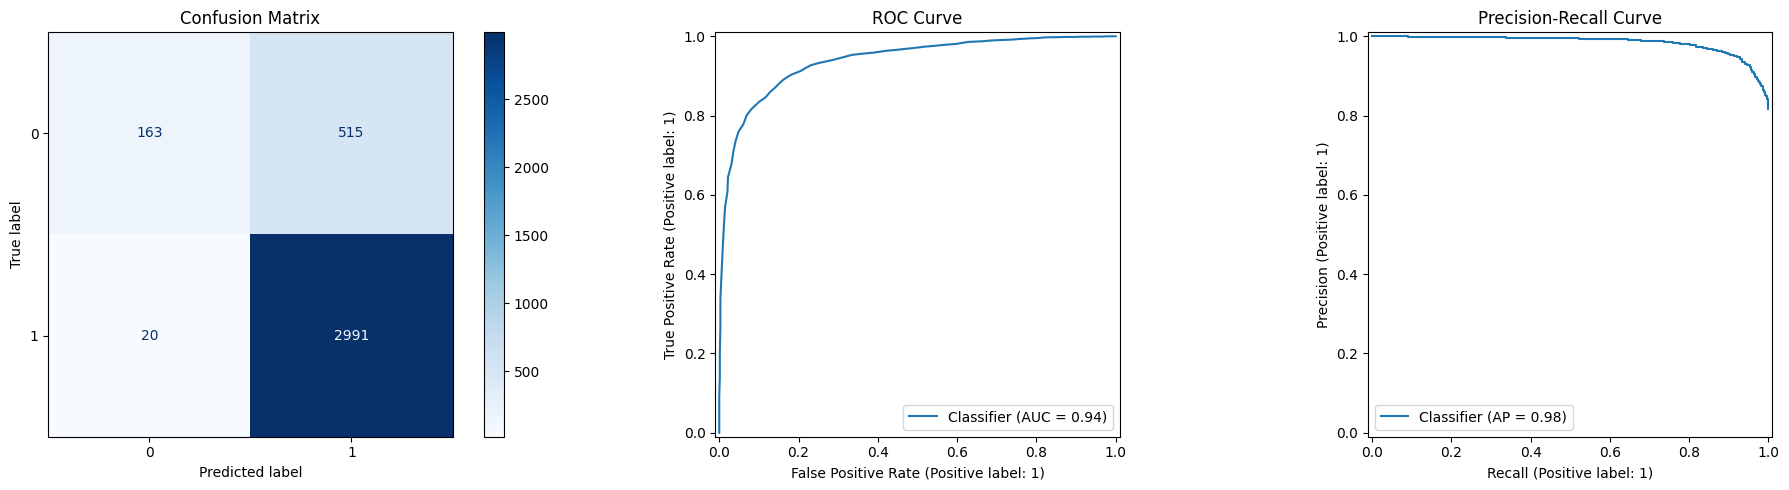

In [56]:
# 2. Print Performance Metrics (Accuracy, Precision, Recall, F1)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_RF_pipeline))
print()

# 3. Visualise some of the metrics I think are important
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix - where the model misclassified rows
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_RF_pipeline, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix")

# ROC Curve - general performance of prediction
RocCurveDisplay.from_predictions(y_test, y_proba_RF_pipeline, ax=ax[1])
ax[1].set_title("ROC Curve")

# Precision-Recall Curve - because of the class imbalance
PrecisionRecallDisplay.from_predictions(y_test, y_proba_RF_pipeline, ax=ax[2])
ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

It is clear from the above low recall and F1 score for 'not recommended, '0', that the model is incorrectly predicting the minority class. ie: only correctlly predicting 'not recommended' ~24% of the time. The overall accuracy and ROC curve are missleadning given the class imbalance. This needs significant improvement. 

In [57]:
# cehck names of pipeline steps
print(RF_model_pipeline.named_steps.keys())

dict_keys(['columntransformer', 'randomforestclassifier'])


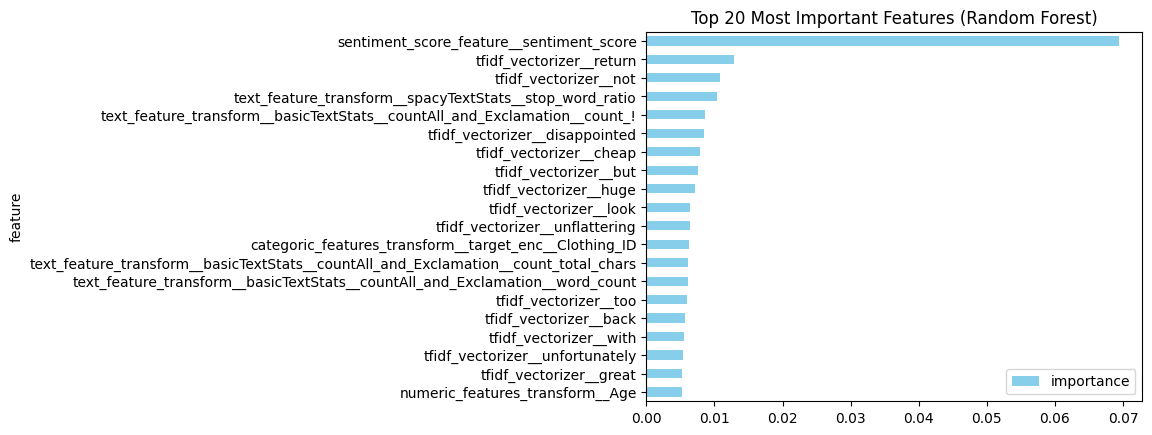

In [58]:
# plot feature importance

# 1. Get the feature names from the preprocessor step
# shuold work becasue we set transform_output="pandas")
feature_names = RF_model_pipeline[:-1].get_feature_names_out()

# 2. Get the importance scores from the classifier
importances = RF_model_pipeline.named_steps['randomforestclassifier'].feature_importances_

# 3. Create a DataFrame for easy plotting
rf_importance = pd.DataFrame({'feature': feature_names, 'importance': importances})
rf_importance = rf_importance.sort_values(by='importance', ascending=False)

# 4. Plot the top 10
rf_importance.head(20).plot(kind='barh', x='feature', y='importance', color='skyblue')
plt.title("Top 20 Most Important Features (Random Forest)")
plt.gca().invert_yaxis() # Put the most important at the top
plt.show()

### Hyperparameter Tuning

#### It is clear that given the imbalanced target the model is not performing well. For RandomForrest used with imbalanced target the documentation suggests setting the hyperparameter 'class_weight' to 'balanced' to beter handle the minority class. Also noted is that it may be better to use StratifiedKFold to ensure each fold maintains the same percentage of minority class as the full dataset, preventing folds with no minority class representation.

In [59]:
# Define parameter grid

param_dist = {
    'randomforestclassifier__n_estimators':[100, 200, 300],                 # number of trees in the forest
    'randomforestclassifier__max_depth':[10, 30, 50],                       # max depth of each tree, limiting helps to prevent overfitting (can't make it too large or i run out of ram!)
    'randomforestclassifier__max_features':['sqrt', 'log2'],                # number of features considered at each split
    'randomforestclassifier__min_samples_split':[2, 5, 10],                 # min samples required to split an internal node
    'randomforestclassifier__min_samples_leaf': [1,2,4],                    # min samples required at a leaf
    'randomforestclassifier__bootstrap': [True,False],                      # bootstrap samples when building trees or not
    'randomforestclassifier__class_weight':['balanced', 'balanced_subsample'] # handle minortiy class better
}



In [60]:
# define Stratified validation 
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# ensure class proportions are part of every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [61]:
# Instantiate RandomizedSearchCV!

rf_randomSearch = RandomizedSearchCV(
    estimator= RF_model_pipeline,
    param_distributions= param_dist,
    n_iter = 4,
    cv=skf,
    scoring = 'average_precision', # apparently better for imbalanced precision/recall curves
    random_state=42,
    n_jobs=1,
    refit=True,     # refit the model using teh best parameters found
    verbose=3      # output the parameters, score and time while running
) 

In [62]:
# run RandomisedSearchCV
rf_randomSearch.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV 1/5] END randomforestclassifier__bootstrap=True, randomforestclassifier__class_weight=balanced, randomforestclassifier__max_depth=30, randomforestclassifier__max_features=log2, randomforestclassifier__min_samples_leaf=4, randomforestclassifier__min_samples_split=5, randomforestclassifier__n_estimators=100;, score=0.981 total time= 2.3min


c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV 2/5] END randomforestclassifier__bootstrap=True, randomforestclassifier__class_weight=balanced, randomforestclassifier__max_depth=30, randomforestclassifier__max_features=log2, randomforestclassifier__min_samples_leaf=4, randomforestclassifier__min_samples_split=5, randomforestclassifier__n_estimators=100;, score=0.976 total time= 1.9min


...

c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV 4/5] END randomforestclassifier__bootstrap=True, randomforestclassifier__class_weight=balanced, randomforestclassifier__max_depth=30, randomforestclassifier__max_features=log2, randomforestclassifier__min_samples_leaf=4, randomforestclassifier__min_samples_split=10, randomforestclassifier__n_estimators=200;, score=0.982 total time= 1.9min


c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV 5/5] END randomforestclassifier__bootstrap=True, randomforestclassifier__class_weight=balanced, randomforestclassifier__max_depth=30, randomforestclassifier__max_features=log2, randomforestclassifier__min_samples_leaf=4, randomforestclassifier__min_samples_split=10, randomforestclassifier__n_estimators=200;, score=0.985 total time= 1.9min


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('numeric_features_transform',
                                                                               Pipeline(steps=[('numeric_imputer',
                                                                                                SimpleImputer())]),
                                                                               ['Age',
                                                                                'Positive_Feedback_Count']),
                                                                              ('categoric_features_transform',
                                                                               Pipeline(steps=[('categoric_impute',
                                                                                                Simpl...
                                        'randomforestclassifier__class_weight': ['balanced',
                                                                                 'balanced_subsample'],
                                        'randomforestclassifier__max_depth': [10,
                                                                              30,
                                                                              50],
                                        'randomforestclassifier__max_features': ['sqrt',
                                                                                 'log2'],
                                        'randomforestclassifier__min_samples_leaf': [1,
                                                                                     2,
                                                                                     4],
                                        'randomforestclassifier__min_samples_split': [2,
                                                                                      5,
                                                                                      10],
                                        'randomforestclassifier__n_estimators': [100,
                                                                                 200,
                                                                                 300]},
                   random_state=42, scoring='average_precision', verbose=3)

In [63]:
# show best parameters and score
print(f'Best parameters \n{rf_randomSearch.best_params_}\n Best Score \n{rf_randomSearch.best_score_}')

Best parameters 
{'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_depth': 50, 'randomforestclassifier__class_weight': 'balanced', 'randomforestclassifier__bootstrap': False}
 Best Score 
0.9862328558578419


In [64]:
# get the best model pipeline that has been refit
model_best = rf_randomSearch.best_estimator_ # this would mean that 'beast_estimator_' contains the 'model_pipeline' previously defined with the updated trained model
model_best

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric_features_transform',
                                                  Pipeline(steps=[('numeric_imputer',
                                                                   SimpleImputer())]),
                                                  ['Age',
                                                   'Positive_Feedback_Count']),
                                                 ('categoric_features_transform',
                                                  Pipeline(steps=[('categoric_impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('categoric_feat_transform',
                                                                   ColumnTransformer(transfo...
                                                                                                                                          nlp=<spacy.lang.en.English object at 0x000001EFA8F9E2D0>))]))]))]),
                                                  ['Title__Review']),
                                                 ('sentiment_score_feature',
                                                  'passthrough',
                                                  ['sentiment_score']),
                                                 ('tfidf_vectorizer',
                                                  Pipeline(steps=[('tfidf_vectorizer',
                                                                   TfidfVectorizer(max_df=0.7))]),
                                                  'lemmatised_text')])),
                ('randomforestclassifier',
                 RandomForestClassifier(bootstrap=False,
                                        class_weight='balanced', max_depth=50,
                                        min_samples_split=5,
                                        random_state=47))])

In [65]:
# 1. Get predictions and probabilities using best tuned model
# 'predict' gives 0 or 1; 'predict_proba' is needed for the ROC/AUC curves
y_pred_RF_pipeline = model_best.predict(X_test)
y_proba_RF_pipeline = model_best.predict_proba(X_test)[:, 1]

c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\meyersea\Python\Lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipe

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.53      0.64       678
           1       0.90      0.97      0.94      3011

    accuracy                           0.89      3689
   macro avg       0.86      0.75      0.79      3689
weighted avg       0.89      0.89      0.88      3689




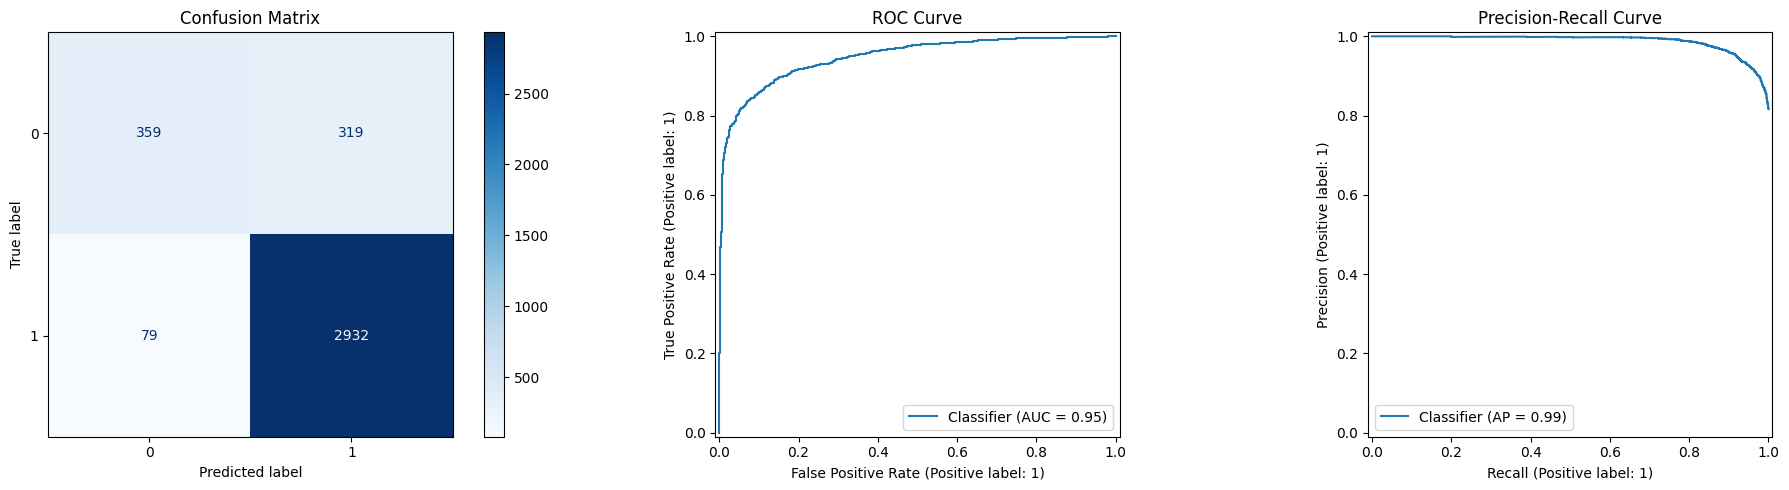

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, 
    RocCurveDisplay, PrecisionRecallDisplay
)


# 2. Print Performance Metrics (Accuracy, Precision, Recall, F1)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_RF_pipeline))
print()

# 3. Visualise some of the metrics I think are important
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix - where the model misclassified rows
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_RF_pipeline, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix")

# ROC Curve - general performance of prediction
RocCurveDisplay.from_predictions(y_test, y_proba_RF_pipeline, ax=ax[1])
ax[1].set_title("ROC Curve")

# Precision-Recall Curve - because of the class imbalance
PrecisionRecallDisplay.from_predictions(y_test, y_proba_RF_pipeline, ax=ax[2])
ax[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

#### After the hyperparameter tuning it is clear there is massive improvement, from 24% to 53% in the classifiers ability to correctly classify the minority class of 'not recommeded' or 0

In [67]:
# cehck names of pipeline steps
print(model_best.named_steps.keys())

dict_keys(['columntransformer', 'randomforestclassifier'])


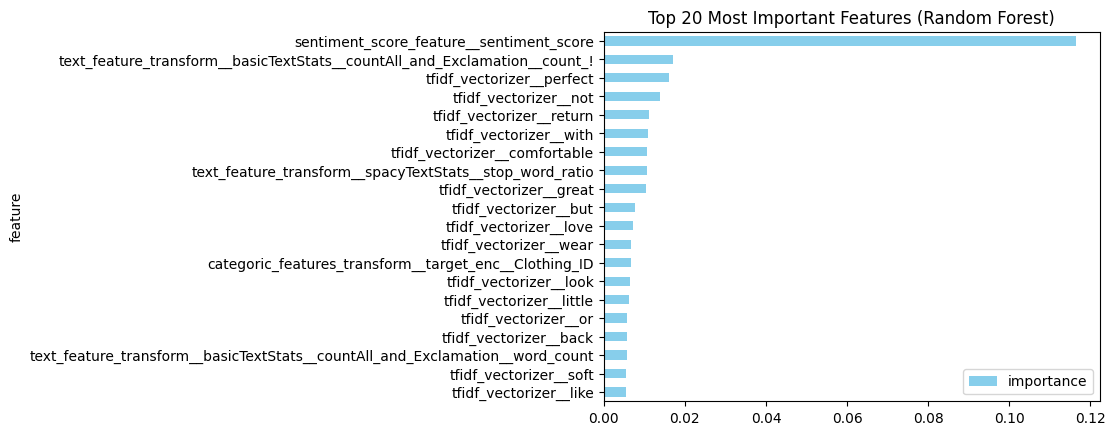

In [68]:
# plot feature importance

# 1. Get the feature names from the preprocessor step
# shuold work becasue we set transform_output="pandas")
feature_names = model_best[:-1].get_feature_names_out()

# 2. Get the importance scores from the classifier
importances = model_best.named_steps['randomforestclassifier'].feature_importances_

# 3. Create a DataFrame for easy plotting
rf_importance = pd.DataFrame({'feature': feature_names, 'importance': importances})
rf_importance = rf_importance.sort_values(by='importance', ascending=False)

# 4. Plot the top 10
rf_importance.head(20).plot(kind='barh', x='feature', y='importance', color='skyblue')
plt.title("Top 20 Most Important Features (Random Forest)")
plt.gca().invert_yaxis() # Put the most important at the top
plt.show()

#### the HF sentiment analysis feature ('sentiment_score') ermains the most important feature to the classifier